# Modality-Invariant Representation Learning for Fair Skin Disease Classification (Version 1)


## Dataset Split

| Role | Dataset | Modality |
|------|---------|----------|
| **Train (paired)** | HIBA | Clinical + Dermoscopic |
| **Train (unpaired clinical)** | Fitzpatrick17k | Clinical |
| **Train (unpaired derm)** | HAM10000 | Dermoscopic |
| **Eval** | Dermnet | Various |

## Unified 7-Class Taxonomy

| ID | Class |
|----|-------|
| 0 | Melanoma |
| 1 | Nevus |
| 2 | Basal Cell Carcinoma |
| 3 | Actinic Keratosis |
| 4 | Seborrheic Keratosis |
| 5 | Squamous Cell Carcinoma |
| 6 | Other |

## Notebook Roadmap

| Phase | Section |
|-------|---------|
| 0 | Environment setup, Drive mount |
| 1 | Data parsers, label harmonization, CSV building, loaders |
| 2 | Dual-encoder ViT architecture |
| 3 | Multi-objective loss functions |
| 4 | Training loop with Drive checkpointing |
| 5 | Fairness evaluation (EOM, PQD, DPM, FATE) |
| 6 | Ablation studies |
| 7 | Visualization (curves, FST bars, cross-dataset, UMAP) |

**Runtime:** T4 GPU or better. Full training ~8–12 h.

## Phase 0 — Environment Setup

In [1]:
!pip install -q timm einops scikit-learn umap-learn \
               matplotlib seaborn pandas tqdm Pillow \
               shap captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 52.4 MB/s eta 0:00:00


In [2]:
import os, re, glob, random, math, json, warnings, shutil
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.model_selection import train_test_split

import shap
from captum.attr import (GradientShap, IntegratedGradients,
                         NoiseTunnel, LayerGradCam, LayerAttribution)
from captum.attr import visualization as viz

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
# ── HuggingFace token + backbone weight cache ────────────────────────────
# Set your HF token as a Kaggle secret (Notebook → Add-ons → Secrets → HF_TOKEN)
# or paste it directly here. Without it, downloads are rate-limited to ~100 KB/s.
import os
_hf_token = os.environ.get('HF_TOKEN', '')
if _hf_token:
    os.environ['HUGGING_FACE_HUB_TOKEN'] = _hf_token
    print(f'HF token loaded ({len(_hf_token)} chars).')
else:
    print('[INFO] No HF_TOKEN found — downloads may be slow. '
          'Add it via Kaggle Secrets → HF_TOKEN.')

# Point timm's weight cache to Kaggle working dir so weights survive
# across kernel restarts and are never re-downloaded.
_BACKBONE_CACHE = Path('/kaggle/working/backbone_cache')
_BACKBONE_CACHE.mkdir(exist_ok=True)
os.environ['TORCH_HOME']     = str(_BACKBONE_CACHE)
os.environ['HF_HOME']        = str(_BACKBONE_CACHE)
os.environ['HUGGINGFACE_HUB_CACHE'] = str(_BACKBONE_CACHE)
print(f'Backbone cache dir: {_BACKBONE_CACHE}')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
[INFO] No HF_TOKEN found — downloads may be slow. Add it via Kaggle Secrets → HF_TOKEN.
Backbone cache dir: /kaggle/working/backbone_cache


In [3]:
# ════════════════════════════════════════════════════════════════════════════
# GLOBAL CONFIG
# ════════════════════════════════════════════════════════════════════════════
DRIVE_ROOT = Path('/kaggle/input/datasets')
WORK_ROOT  = Path('/kaggle/working')

CFG = dict(
    # Dataset roots  (read-only)
    hiba_root     = DRIVE_ROOT / 'asosenge/hibaskinlesionsdataset-main',
    fitz_root     = DRIVE_ROOT / 'asosenge/fitzpatrick17k',
    ham_root      = DRIVE_ROOT / 'asosenge/ham10000',
    dermnet_root  = DRIVE_ROOT / 'shubhamgoel27/dermnet',
    # Outputs  (writable)
    csv_dir       = WORK_ROOT / 'csvs',
    ckpt_dir      = WORK_ROOT / 'checkpoints',
    results_dir   = WORK_ROOT / 'results',
    shap_dir      = WORK_ROOT / 'results/shap',
    # Architecture
    backbone      = 'vit_small_patch16_224',
    embed_dim     = 512,
    img_size      = 224,
    # Training
    batch_size    = 32,
    num_epochs    = 15,
    lr            = 1e-4,
    weight_decay  = 1e-4,
    warmup_epochs = 5,
    # Loss weights
    lambda_cls    = 1.0,
    lambda_conf   = 0.5,
    lambda_con    = 0.5,
    lambda_mi     = 1.0,
    temperature   = 0.07,
    # Labels — 7 canonical classes (0-5 + "other")
    num_classes    = 7,
    num_skin_types = 6,
    # Data balancing (applied to train split only via oversampling in the CSV)
    aug_target_per_class = 3000,
    aug_target_per_fst   = 500,
    # Ablation flags
    use_conf = True, use_con = True, use_mi = True,
)

# ── Canonical label names (all lowercase, no hyphens, consistent spacing) ──
LABEL_NAMES = {
    0: 'melanoma',
    1: 'nevus',
    2: 'basal cell carcinoma',
    3: 'actinic keratosis',
    4: 'seborrheic keratosis',
    5: 'squamous cell carcinoma',
    6: 'other',
}
FST_NAMES = {i: f'FST {i+1}' for i in range(6)}

for k in ['csv_dir','ckpt_dir','results_dir','shap_dir']:
    CFG[k].mkdir(parents=True, exist_ok=True)

print('Config ready. Checking dataset roots:')
for k in ['hiba_root','fitz_root','ham_root','dermnet_root']:
    status = 'OK' if CFG[k].exists() else 'MISSING — update path'
    print(f'  [{status}]  {k}')


Config ready. Checking dataset roots:
  [OK]  hiba_root
  [OK]  fitz_root
  [OK]  ham_root
  [OK]  dermnet_root


## Phase 1 — Data Preparation

### 1-A  Label Taxonomy & Mapping Tables

In [4]:
# ════════════════════════════════════════════════════════════════════════════
# LABEL TAXONOMY & MAPPING TABLES
# ════════════════════════════════════════════════════════════════════════════
# Canonical 7 classes (verified against actual CSV values):
#   0  melanoma
#   1  nevus
#   2  basal cell carcinoma
#   3  actinic keratosis
#   4  seborrheic keratosis
#   5  squamous cell carcinoma
#   6  other

import re as _re

def _clean(s: str) -> str:
    """Lowercase, strip, normalise hyphens/underscores to spaces."""
    s = str(s).lower().strip()
    s = _re.sub(r'[-_]+', ' ', s)
    s = _re.sub(r'\s+', ' ', s)
    return s

# ── HAM10000  (dx codes verified from HAM10000_metadata.csv) ─────────────
# nv=nevus  mel=melanoma  bkl=benign keratosis(→seborrheic)
# bcc=BCC  akiec=AK/SCC-in-situ(→AK)  vasc=vascular(→other)  df=dermatofibroma(→other)
HAM_MAP = {
    'mel':   0,   # melanoma
    'nv':    1,   # nevus
    'bcc':   2,   # basal cell carcinoma
    'akiec': 3,   # actinic keratosis (HAM groups AK + SCC in-situ together)
    'bkl':   4,   # benign / seborrheic keratosis
    'df':    6,   # dermatofibroma → other
    'vasc':  6,   # vascular lesion → other
}

# ── HIBA  (diagnosis column — verified from hospital-italiano CSV) ────────
# Exact strings in the column (already English, already clean):
HIBA_MAP = {
    'melanoma':                0,
    'solar lentigo':           0,   # melanocytic / lentiginous → melanoma group
    'nevus':                   1,
    'basal cell carcinoma':    2,
    'actinic keratosis':       3,
    'seborrheic keratosis':    4,
    'lichenoid keratosis':     4,   # benign keratosis variant
    'squamous cell carcinoma': 5,
    'dermatofibroma':          6,
    'vascular lesion':         6,
}

# ── Fitzpatrick17k  ('label' column — verified from fitzpatrick17k.csv) ───
# The code MUST read the 'label' column (fine-grained diagnoses), NOT
# 'nine_partition_label' (which contains only coarse groups like "inflammatory"
# that map almost entirely to class 6 = other).
FITZ_MAP = {
    # ── Melanoma (0) ────────────────────────────────────────────────────
    'melanoma':                              0,
    'malignant melanoma':                   0,
    'superficial spreading melanoma ssm':   0,
    'lentigo maligna':                      0,
    'lentigo maligna melanoma':             0,
    'acral lentiginous melanoma':           0,
    'nodular melanoma':                     0,
    # ── Nevus (1) ───────────────────────────────────────────────────────
    'nevocytic nevus':                      1,
    'epidermal nevus':                      1,
    'congenital nevus':                     1,
    'halo nevus':                           1,
    'becker nevus':                         1,
    'nevus sebaceous of jadassohn':         1,
    'naevus comedonicus':                   1,
    # ── Basal Cell Carcinoma (2) ─────────────────────────────────────────
    'basal cell carcinoma':                 2,
    'basal cell carcinoma morpheiform':     2,
    'solid cystic basal cell carcinoma':    2,
    # ── Actinic Keratosis (3) ────────────────────────────────────────────
    'actinic keratosis':                    3,
    'porokeratosis actinic':               3,   # actinic variant
    'squamous cell carcinoma in situ':     3,   # SCC in-situ grouped with AK
    'bowens disease':                      3,
    'keratoacanthoma':                     3,
    # ── Seborrheic Keratosis (4) ─────────────────────────────────────────
    'seborrheic keratosis':                4,
    'seborrhoeic keratosis':               4,
    'lichenoid keratosis':                 4,
    'benign keratosis':                    4,
    # ── Squamous Cell Carcinoma (5) ──────────────────────────────────────
    'squamous cell carcinoma':             5,
    # ── Other (6) ────────────────────────────────────────────────────────
    'dermatofibroma':                      6,
    'kaposi sarcoma':                      6,
    'mycosis fungoides':                   6,
    'malignant cutaneous lymphoma':        6,
}

# ── DermNet  (folder-level fallback — per-image from filename in parser) ──
DERMNET_FOLDER_MAP = {
    'melanoma skin cancer nevi and moles':                               0,
    'actinic keratosis basal cell carcinoma and other malignant lesions': 2,
    'seborrheic keratoses and other benign tumors':                       4,
}

def harmonize_label(raw: str, mapping: dict, default: int = 6) -> int:
    """Map a raw diagnosis string → canonical class integer.

    Order of operations:
    1. _clean() — lowercase, strip, normalise hyphens.
    2. Exact match in mapping.
    3. Substring match (key in string OR string in key).
    4. Wildcard: any string containing the word 'nevus' → class 1.
    5. Return default (6 = other).
    """
    s = _clean(raw)
    if s in mapping:
        return mapping[s]
    for k, v in mapping.items():
        if k in s or s in k:
            return v
    if 'nevus' in s or 'nevi' in s:
        return 1
    return default

def parse_fst(raw) -> int:
    """Parse an integer Fitzpatrick skin type (1–6) → index (0–5).
    Returns -1 for missing / out-of-range values.
    """
    try:
        v = int(float(str(raw).strip()))
        return v - 1 if 1 <= v <= 6 else -1
    except (ValueError, TypeError):
        return -1

_ROMAN_TO_INT = {
    'i': 1, 'ii': 2, 'iii': 3, 'iv': 4, 'v': 5, 'vi': 6,
}
def parse_fst_roman(raw) -> int:
    """Parse roman-numeral or integer FST (HIBA uses I–VI strings).
    Returns 0-based index (0=FST I … 5=FST VI), or -1 if unparseable.
    """
    s = str(raw).lower().strip()
    if s in _ROMAN_TO_INT:
        return _ROMAN_TO_INT[s] - 1
    return parse_fst(raw)   # fallback to integer parsing

print('Label taxonomy ready — 7 classes verified against real CSV values.')
print('  FITZ: reads \"label\" column (fine-grained diagnoses)')
print('  HIBA: reads \"diagnosis\" column + \"fitzpatrick_skin_type\" (roman numerals)')
print('  HAM:  reads \"dx\" column + ITA-estimated FST')


Label taxonomy ready — 7 canonical classes.
  0: melanoma  1: nevus  2: basal cell carcinoma  3: actinic keratosis
  4: seborrheic keratosis  5: squamous cell carcinoma  6: other


### 1-B  Dataset Parsers

In [5]:
# ════════════════════════════════════════════════════════════════════════════
# PAIRED PARSERS  (Derm7pt  &  HIBA)
# ════════════════════════════════════════════════════════════════════════════

def _safe_split(df, test_size=0.15, seed=42):
    """Stratified split.  Classes with only 1 sample are kept in train only
    (stratify would fail; a singleton class can't appear in both splits)."""
    if df.empty: return df, df
    # Count samples per class; singletons can't be stratified
    cts      = df['label'].value_counts()
    rare     = cts[cts < 2].index
    df_rare  = df[df['label'].isin(rare)]
    df_rest  = df[~df['label'].isin(rare)]
    if df_rest.empty:
        return df, df.iloc[:0]          # all rare — put everything in train
    try:
        tr, va = train_test_split(df_rest, test_size=test_size,
                                  random_state=seed, stratify=df_rest['label'])
    except ValueError:
        tr, va = train_test_split(df_rest, test_size=test_size, random_state=seed)
    # Rare-class samples go to train only (they can't contribute to val AUROC anyway)
    tr = pd.concat([tr, df_rare], ignore_index=True)
    return tr, va



def _safe_split_3way(df, val_size=0.15, test_size=0.15, seed=42):
    """Three-way stratified split → (train, val, test).

    Proportions (of the full df):
        val  ≈ val_size   (default 15 %)
        test ≈ test_size  (default 15 %)
        train = remainder (~70 %)

    Rare classes (< 2 samples) are kept in train only.
    """
    if df.empty:
        return df, df.iloc[:0], df.iloc[:0]

    cts     = df['label'].value_counts()
    rare    = cts[cts < 2].index
    df_rare = df[df['label'].isin(rare)]
    df_rest = df[~df['label'].isin(rare)]

    if df_rest.empty:
        return df, df.iloc[:0], df.iloc[:0]

    # First carve off the test split from the full remainder
    try:
        df_tv, df_test = train_test_split(
            df_rest, test_size=test_size,
            random_state=seed, stratify=df_rest['label'])
    except ValueError:
        df_tv, df_test = train_test_split(
            df_rest, test_size=test_size, random_state=seed)

    # Then carve val from the train+val portion
    # val_size is expressed relative to the *original* df, so rescale
    rel_val = val_size / (1.0 - test_size)
    try:
        df_train, df_val = train_test_split(
            df_tv, test_size=rel_val,
            random_state=seed, stratify=df_tv['label'])
    except ValueError:
        df_train, df_val = train_test_split(
            df_tv, test_size=rel_val, random_state=seed)

    df_train = pd.concat([df_train, df_rare], ignore_index=True)
    return df_train, df_val, df_test

print('Split helpers ready.')


Split helpers ready.


In [6]:
# ════════════════════════════════════════════════════════════════════════════
# HIBA PARSER
# ════════════════════════════════════════════════════════════════════════════

def parse_hiba(root: Path):
    """Parse the HIBA dataset.

    Key facts from the CSV (verified):
    - 1 row = 1 image.  1246 unique lesion_ids, 1616 rows total.
    - image_type values: "dermoscopic" | "clinical: overview" | "clinical: close-up"
    - diagnosis column: already English, clean strings.
    - fitzpatrick_skin_type column: roman numerals I–IV (I=most common, no VI found).
    - Only 267 lesions have BOTH clinical + dermoscopic → used as paired rows.
    - The remaining 979 lesions are treated as unpaired clinical or unpaired derm rows.
      WITHOUT this, BCC/SCC/AK/seborrheic keratosis from HIBA are entirely lost.

    Returns:
        paired_tr, paired_va, paired_te   — paired (clinical+derm) split DataFrames
        Sets _hiba_unpaired_splits = (tr_u, va_u, te_u) for the clinical+derm unpaired pools.
    """
    candidates = (
        list(root.rglob('metadata.csv')) +
        list(root.rglob('hiba_metadata.csv')) +
        list(root.rglob('hospital-italiano-de-buenos-aires-skin-lesions-images-2019-2022.csv'))
    )
    if not candidates:
        print(f'[WARN] HIBA: no metadata CSV under {root}')
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    meta = pd.read_csv(candidates[0])
    print(f'[HIBA] {len(meta)} rows | columns: {list(meta.columns)}')

    # Validate required columns
    for req in ['isic_id', 'image_type', 'lesion_id', 'diagnosis']:
        if req not in meta.columns:
            print(f'[WARN] HIBA: required column "{req}" missing'); return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    fst_col = next((c for c in ['fitzpatrick_skin_type', 'fitzpatrick', 'fitzpatrick_scale']
                    if c in meta.columns), None)
    print(f'[HIBA] FST column: {fst_col}')

    image_path_map = _build_image_map(root)
    print(f'[HIBA] image map: {len(image_path_map)} entries')

    # ── Per-lesion accumulation ───────────────────────────────────────
    lesion_data = {}   # lesion_id → {label, fst, clinical:[], derm:[]}
    for _, r in meta.iterrows():
        lid   = str(r['lesion_id'])
        itype = _clean(str(r.get('image_type', '')))
        isic  = str(r.get('isic_id', ''))
        diag  = str(r.get('diagnosis', 'other'))
        fst   = parse_fst_roman(r[fst_col]) if fst_col else -1

        # Resolve image path
        img_path = image_path_map.get(isic)
        if img_path is None and '.' in isic:
            img_path = image_path_map.get(Path(isic).stem)

        if lid not in lesion_data:
            lesion_data[lid] = {
                'label': harmonize_label(diag, HIBA_MAP),
                'fst':   fst,
                'clinical': [],
                'derm':    [],
            }
        else:
            # Update FST if we now have a valid value
            if fst >= 0 and lesion_data[lid]['fst'] < 0:
                lesion_data[lid]['fst'] = fst

        if img_path:
            if 'derm' in itype:
                lesion_data[lid]['derm'].append(str(img_path))
            else:
                # "clinical: overview" and "clinical: close-up" are both clinical
                lesion_data[lid]['clinical'].append(str(img_path))

    # ── Build rows ────────────────────────────────────────────────────
    paired_rows   = []   # lesions with both modalities
    unpaired_clin = []   # clinical-only images  →  clin_* pool
    unpaired_derm = []   # derm-only images      →  derm_* pool

    for lid, d in lesion_data.items():
        label = d['label']; fst = d['fst']
        base = {'label': label, 'skin_type': fst, 'dataset': 'hiba'}

        if d['clinical'] and d['derm']:
            # Paired: use first of each modality
            paired_rows.append({
                **base,
                'lesion_id':     f'hiba_{lid}',
                'clinical_path': d['clinical'][0],
                'derm_path':     d['derm'][0],
            })
            # Extra clinical images beyond the first also go to unpaired pool
            for p in d['clinical'][1:]:
                unpaired_clin.append({**base, 'image_path': p})
            for p in d['derm'][1:]:
                unpaired_derm.append({**base, 'image_path': p})
        else:
            for p in d['clinical']:
                unpaired_clin.append({**base, 'image_path': p})
            for p in d['derm']:
                unpaired_derm.append({**base, 'image_path': p})

    df_paired = pd.DataFrame(paired_rows)
    df_uclin  = pd.DataFrame(unpaired_clin)
    df_uderm  = pd.DataFrame(unpaired_derm)

    # ── Split each pool ───────────────────────────────────────────────
    tr_p, va_p, te_p = _safe_split_3way(df_paired) if not df_paired.empty else (pd.DataFrame(),)*3
    tr_uc, va_uc, te_uc = _safe_split_3way(df_uclin) if not df_uclin.empty else (pd.DataFrame(),)*3
    tr_ud, va_ud, te_ud = _safe_split_3way(df_uderm) if not df_uderm.empty else (pd.DataFrame(),)*3

    global _hiba_unpaired_splits
    _hiba_unpaired_splits = (tr_uc, va_uc, te_uc, tr_ud, va_ud, te_ud)

    print(f'[HIBA] paired    : {len(tr_p)} train | {len(va_p)} val | {len(te_p)} test')
    print(f'[HIBA] unpaired clin: {len(tr_uc)} train | {len(va_uc)} val | {len(te_uc)} test')
    print(f'[HIBA] unpaired derm: {len(tr_ud)} train | {len(va_ud)} val | {len(te_ud)} test')

    # Class distribution for paired
    if not df_paired.empty:
        vc = df_paired['label'].value_counts().sort_index()
        print('[HIBA paired] classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc.items()))
    # Class distribution for all HIBA images
    all_hiba = pd.concat([df_paired.rename(columns={'clinical_path':'image_path'}).get(['label','skin_type'],pd.DataFrame()),
                           df_uclin[['label','skin_type']] if not df_uclin.empty else pd.DataFrame(),
                           df_uderm[['label','skin_type']] if not df_uderm.empty else pd.DataFrame()])
    if not all_hiba.empty:
        vc2 = all_hiba['label'].value_counts().sort_index()
        print('[HIBA total  ] classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc2.items()))
        n_fst = int((all_hiba['skin_type'] >= 0).sum())
        print(f'[HIBA] FST known: {n_fst}/{len(all_hiba)} images')

    return tr_p, va_p, te_p

_hiba_unpaired_splits = (pd.DataFrame(),)*6
print('HIBA parser ready.')


Paired parsers ready.


In [7]:
# ════════════════════════════════════════════════════════════════════════════
# UNPAIRED CLINICAL PARSERS  (Fitzpatrick17k | PAD-UFES-20 | DDI)
# ════════════════════════════════════════════════════════════════════════════

def _find_image(img_id, search_dirs, exts=['.jpg','.jpeg','.png'], recursive=False):
    for d in search_dirs:
        for e in exts:
            if recursive:
                # Use rglob for recursive search
                candidates = list(d.rglob(f'{img_id}{e}'))
                if candidates:
                    return candidates[0]
            else:
                # Non-recursive search, directly in the specified directory
                p = d / f'{img_id}{e}'
                if p.exists(): return p
    return None

def _build_image_map(root_dir: Path, exts=['.jpg','.jpeg','.png']):
    """Recursively builds a map from image filename (stem and full name) to its full path."""
    image_map = {}
    for ext in exts:
        for p in root_dir.rglob(f'*{ext}'):
            image_map[p.stem] = p
            image_map[p.name] = p 
    return image_map

def parse_fitzpatrick17k(root: Path):
    csvs = list(root.glob('fitzpatrick17k.csv'))
    if not csvs: print(f'[WARN] Fitzpatrick17k CSV missing'); return pd.DataFrame(), pd.DataFrame()
    meta    = pd.read_csv(csvs[0])
    img_dir = root/'data/finalfitz17k' if (root/'data/finalfitz17k').exists() else root

    print(f'[DEBUG FITZ] Building image path map for {img_dir}...')
    image_path_map = _build_image_map(img_dir)
    print(f'[DEBUG FITZ] Image map built with {len(image_path_map)} entries.')

    rows = []
    for _, r in meta.iterrows():
        # fitzpatrick_scale: int column, values 1-6, -1 = unknown
        _fst_raw = r.get('fitzpatrick_scale', r.get('fitzpatrick', -1))
        fst = parse_fst(_fst_raw) if str(_fst_raw).strip() not in ('-1', '-1.0', 'nan', '') else -1
        p   = None
        for col in ['md5hash','image_id','file_name']:
            if col in r.index and pd.notna(r[col]):
                candidate_id = str(r[col])
                p = image_path_map.get(candidate_id)
                if p: break
                # If meta ID is full filename, try lookup by stem
                if '.' in candidate_id:
                    p = image_path_map.get(Path(candidate_id).stem)
                    if p: break
        if p is None and 'url' in r.index:
            base = str(r['url']).split('/')[-1].split('?')[0]
            p = image_path_map.get(base)
            if p is None and '.' in base:
                p = image_path_map.get(Path(base).stem)
        if p is None: continue
        # BUG FIX: read 'label' (fine-grained diagnosis) NOT 'nine_partition_label'
        # (which contains only coarse groups like "inflammatory" → almost all map to class 6)
        raw = str(r.get('label', r.get('nine_partition_label', 'other')))
        rows.append({'image_path': str(p), 'label': harmonize_label(raw, FITZ_MAP),
                     'skin_type': fst, 'dataset': 'fitzpatrick17k'})
    df = pd.DataFrame(rows)
    tr, va, te = _safe_split_3way(df)
    fst_known_count = 0
    if not df.empty and 'skin_type' in df.columns:
        fst_known_count = (df.skin_type>=0).sum()
    print(f'Fitzpatrick17k — {len(tr):>6} train  {len(va):>5} val  {len(te):>5} test  | FST known: {fst_known_count}')
    vc = df['label'].value_counts().sort_index()
    print('  classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc.items()))
    return tr, va, te


print('Clinical parsers ready.')

Clinical parsers ready.


In [8]:
# ════════════════════════════════════════════════════════════════════════════
# UNPAIRED DERM PARSERS  (HAM10000 | ISIC 2018)
# ════════════════════════════════════════════════════════════════════════════

def parse_ham10000(root: Path):
    # rglob searches recursively — finds the CSV wherever it lives under root
    csvs = list(root.rglob('HAM10000_metadata.csv'))
    if not csvs:
        print('[WARN] HAM10000 CSV missing'); return pd.DataFrame(), pd.DataFrame()
    
    meta_path = csvs[0]
    meta_root = meta_path.parent          # e.g. .../ham10000/HAM10000/
    print(f'[DEBUG HAM] Found metadata at: {meta_path}')
    meta = pd.read_csv(meta_path)

    # Search for images relative to where the CSV lives, plus common subfolder patterns
    img_dirs = (
        [meta_root/'images'] +
        [meta_root/f'HAM10000_images_part_{i}' for i in [1, 2]] +
        [meta_root/f'images_part_{i}'          for i in [1, 2]] +
        [meta_root]                             # fallback: same folder as CSV
    )

    print(f'[DEBUG HAM] Building image path map...')
    image_path_map = _build_image_map(meta_root)
    print(f'[DEBUG HAM] Image map built with {len(image_path_map)} entries.')

    rows = []
    for _, r in meta.iterrows():
        img_id = str(r.get('image_id', ''))
        dx     = str(r.get('dx', 'other')).lower().strip()
        # Try the map first (fast), fall back to directory search
        p = image_path_map.get(img_id) or _find_image(img_id, img_dirs)
        if p:
            rows.append({'image_path': str(p), 'label': HAM_MAP.get(dx, 6),
                         'skin_type': -1, 'dataset': 'ham10000'})

    df = pd.DataFrame(rows)
    tr, va, te = _safe_split_3way(df)
    print(f'HAM10000       — {len(tr):>6} train  {len(va):>5} val  {len(te):>5} test')
    return tr, va, te

print('Dermoscopic parsers ready.')

Dermoscopic parsers ready.


In [9]:
# ════════════════════════════════════════════════════════════════════════════
# EVALUATION DATASET PARSERS  (DermNet | generic folder)
# ════════════════════════════════════════════════════════════════════════════

def _dermnet_label_from_filename(stem: str, folder_label: int) -> int:
    """Derive a fine-grained class from a DermNet image filename stem.

    DermNet images live in coarse folders but carry detailed diagnosis
    information in their filenames (hyphen-separated tokens).  We use
    _clean() to normalise them then check for class-specific tokens.

    Folder "Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions":
      actinic-keratosis-*   → 3
      basal-cell-carcinoma-* → 2
      squamous-cell-carcinoma-* → 5

    Folder "Seborrheic Keratoses and other Benign Tumors":
      20seborrheicKeratosisCrop → 4  (no hyphens, normalised)
      melanoma-mimic-*          → 0  (mimics melanoma)
      nevus-sebaceous-*         → 1  (nevus variant)
      seborrheic-keratoses-*    → 4

    Folder "Melanoma Skin Cancer Nevi and Moles":
      nevi / nevus / moles tokens → 1
      everything else             → 0 (melanoma)
    """
    s = _clean(stem)   # lowercase, hyphens → spaces
    # Fine-grained token rules (most-specific first)
    if 'squamous cell carcinoma' in s or 'squamous' in s:
        return 5
    if 'basal cell carcinoma' in s or ('basal' in s and 'cell' in s):
        return 2
    if 'actinic keratosis' in s or 'actinic' in s:
        return 3
    if 'nevus' in s or 'nevi' in s or 'mole' in s:
        return 1
    if 'melanoma mimic' in s or 'mimic' in s:
        return 0
    if 'seborrheic' in s or 'seborrhoeic' in s or 'seborrhe' in s:
        return 4
    # Fall back to the folder-level label
    return folder_label


def parse_dermnet(root: Path) -> pd.DataFrame:
    """Walk DermNet root; assign per-image labels using filename + folder heuristic."""
    rows = []
    for folder in sorted(root.rglob('*')):
        if not folder.is_dir():
            continue
        folder_clean = _clean(folder.name)
        folder_label = harmonize_label(folder_clean, DERMNET_FOLDER_MAP, default=6)
        for f in folder.iterdir():
            if f.suffix.lower() not in ['.jpg', '.jpeg', '.png']:
                continue
            img_label = _dermnet_label_from_filename(f.stem, folder_label)
            rows.append({
                'image_path': str(f),
                'label':      img_label,
                'skin_type':  -1,
                'dataset':    'dermnet',
            })
    df = pd.DataFrame(rows)
    print(f'DermNet          (eval) — {len(df):>6} images')
    if not df.empty:
        vc = df['label'].value_counts().sort_index()
        for lbl, cnt in vc.items():
            print(f'  class {lbl} ({LABEL_NAMES.get(lbl,"?")}): {cnt}')
    return df


# ── ITA-based Fitzpatrick Skin Type estimator ─────────────────────────────
_ITA_BRACKETS = [
    ( 55.0,  float('inf'), 0),
    ( 28.0,  55.0,         1),
    ( 10.0,  28.0,         2),
    (-30.0,  10.0,         3),
    (-55.0, -30.0,         4),
    (float('-inf'), -55.0, 5),
]

def _ita_to_fst(ita: float) -> int:
    for lo, hi, fst in _ITA_BRACKETS:
        if lo < ita <= hi:
            return fst
    return _ITA_BRACKETS[-1][2]

def _estimate_fst_single(path: str, min_skin_frac: float = 0.05, thumb_size: int = 96) -> int:
    try:
        from skimage import color as _skcolor
        img = Image.open(path).convert('RGB')
        img = img.resize((thumb_size, thumb_size), Image.BILINEAR)
        rgb = np.asarray(img, dtype=np.float32) / 255.0
        lab = _skcolor.rgb2lab(rgb)
        L, a, b = lab[..., 0], lab[..., 1], lab[..., 2]
        skin_mask = (L > 20) & (L < 90) & (a > 2) & (b > 5)
        if skin_mask.mean() < min_skin_frac:
            return -1
        mean_L = float(L[skin_mask].mean())
        mean_b = float(b[skin_mask].mean())
        if abs(mean_b) < 1e-6:
            return -1
        return _ita_to_fst(float(np.degrees(np.arctan((mean_L - 50.0) / mean_b))))
    except Exception:
        return -1

def estimate_fst_for_csv(df: pd.DataFrame, n_jobs: int = 4, cache_csv: Path = None) -> pd.DataFrame:
    if cache_csv is not None and Path(cache_csv).exists():
        cached = pd.read_csv(cache_csv)
        if 'skin_type' in cached.columns and len(cached) == len(df):
            df = df.copy()
            df['skin_type'] = cached['skin_type'].values
            print(f'  [FST cache] loaded {(df["skin_type"]>=0).sum()}/{len(df)} from {Path(cache_csv).name}')
            return df
    print(f'  Estimating FST via ITA for {len(df)} images (n_jobs={n_jobs}) …')
    from concurrent.futures import ThreadPoolExecutor
    paths = df['image_path'].tolist()
    with ThreadPoolExecutor(max_workers=n_jobs) as ex:
        fst_values = list(tqdm(ex.map(_estimate_fst_single, paths),
                               total=len(paths), desc='  ITA-FST', leave=True))
    df = df.copy()
    df['skin_type'] = fst_values
    n_known = sum(v >= 0 for v in fst_values)
    print(f'  FST estimated: {n_known}/{len(df)} ({100*n_known/max(len(df),1):.1f}%)')
    for fi in range(6):
        cnt = sum(v == fi for v in fst_values)
        if cnt: print(f'    FST {fi+1}: {cnt:>5}')
    if cache_csv is not None:
        df.to_csv(cache_csv, index=False)
        print(f'  Saved FST cache → {Path(cache_csv).name}')
    return df

print('Evaluation parsers + ITA-FST estimator ready.')


Evaluation parsers + ITA-FST estimator ready.


### 1-C  Build CSVs & Data Loaders

In [10]:
# ════════════════════════════════════════════════════════════════════════════
# BUILD ALL CSVs
# Pipeline (fixes class imbalance at the root):
#   1. Parse every dataset → raw rows, no augmentation
#   2. Pool same-modality rows from ALL datasets into combined DataFrames
#   3. Split each combined pool ONCE with stratified 70/15/15
#      → every class & FST group is proportional in EVERY split
#   4. Augment ONLY the combined train splits (val/test stay natural)
# ════════════════════════════════════════════════════════════════════════════

def augment_balanced(df, target_per_class=3000, target_per_fst=500, seed=42):
    """Oversample minority classes and rare FST groups — TRAIN SPLIT ONLY.

    Oversampled rows point to the same real files; the rich train_tfm
    (RandomCrop, ColorJitter, GaussianBlur, RandomErasing…) produces a
    different tensor on every access, so this is genuine augmentation.
    Val/test are NOT augmented — their natural distribution is needed for
    honest metric computation (especially EOM, PQD, Macro-F1).
    """
    if df.empty:
        return df
    rng = np.random.default_rng(seed)

    # Pass 1: class balance
    parts = []
    for cls in sorted(df['label'].unique()):
        sub = df[df['label'] == cls]
        if len(sub) < target_per_class:
            extra = sub.sample(n=target_per_class - len(sub), replace=True,
                               random_state=int(rng.integers(1_000_000)))
            parts.append(pd.concat([sub, extra], ignore_index=True))
        else:
            parts.append(sub)
    df_bal = pd.concat(parts, ignore_index=True)

    # Pass 2: FST balance (known FST groups only)
    if 'skin_type' in df_bal.columns:
        fst_parts, df_unk = [], df_bal[df_bal['skin_type'] < 0]
        for fst in range(6):
            sub = df_bal[df_bal['skin_type'] == fst]
            if sub.empty: continue
            if len(sub) < target_per_fst:
                extra = sub.sample(n=target_per_fst - len(sub), replace=True,
                                   random_state=int(rng.integers(1_000_000)))
                fst_parts.append(pd.concat([sub, extra], ignore_index=True))
            else:
                fst_parts.append(sub)
        if fst_parts:
            df_bal = pd.concat(fst_parts + [df_unk], ignore_index=True)

    return df_bal.sample(frac=1, random_state=seed).reset_index(drop=True)


def _verify_labels(df, name, n_classes=7):
    """Drop rows with out-of-range labels and print a per-class summary."""
    if df.empty: return df
    before = len(df)
    df = df[df['label'].between(0, n_classes - 1)].copy()
    if before - len(df):
        print(f'  [WARN] {name}: dropped {before-len(df)} out-of-range rows')
    vc = df['label'].value_counts().sort_index()
    print(f'  {name}: {len(df)} rows | ' +
          '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k, v in vc.items()))
    return df


# ── Step 1: Parse ──────────────────────────────────────────────────────────
print('='*60, '\nParsing datasets ...')
hiba_tr_p, hiba_va_p, hiba_te_p = parse_hiba(CFG['hiba_root'])
# _hiba_unpaired_splits = (tr_uclin, va_uclin, te_uclin, tr_uderm, va_uderm, te_uderm)
hiba_tr_uc, hiba_va_uc, hiba_te_uc, hiba_tr_ud, hiba_va_ud, hiba_te_ud = _hiba_unpaired_splits

fitz_tr, fitz_va, fitz_te = parse_fitzpatrick17k(CFG['fitz_root'])
ham_tr,  ham_va,  ham_te  = parse_ham10000(CFG['ham_root'])

# ── Step 2: Combine into three pools ──────────────────────────────────────
# Pool A — HIBA paired (clinical+dermoscopic → used for L_MI loss)
df_paired_all = pd.concat([hiba_tr_p, hiba_va_p, hiba_te_p], ignore_index=True)

# Pool B — Unpaired clinical (Fitzpatrick17k + HIBA clinical-only)
df_clin_all = pd.concat([fitz_tr, fitz_va, fitz_te,
                          hiba_tr_uc, hiba_va_uc, hiba_te_uc], ignore_index=True)

# Pool C — Unpaired derm (HAM10000 + HIBA derm-only)
df_derm_all = pd.concat([ham_tr, ham_va, ham_te,
                          hiba_tr_ud, hiba_va_ud, hiba_te_ud], ignore_index=True)

# Verify labels
print('\nLabel verification ...')
df_paired_all = _verify_labels(df_paired_all, 'HIBA paired (all)')
df_clin_all   = _verify_labels(df_clin_all,   'Clinical unpaired (all)')
df_derm_all   = _verify_labels(df_derm_all,   'Derm unpaired (all)')

# ── Step 3: Split combined pools ONCE ─────────────────────────────────────
# Single stratified split guarantees every class and FST in every split.
print('\nSplitting combined pools (70/15/15 stratified) ...')
paired_train, paired_val, paired_test = _safe_split_3way(df_paired_all, seed=SEED)
clin_train,   clin_val,   clin_test   = _safe_split_3way(df_clin_all,   seed=SEED)
derm_train,   derm_val,   derm_test   = _safe_split_3way(df_derm_all,   seed=SEED)

print(f'  Paired  : {len(paired_train)} tr | {len(paired_val)} va | {len(paired_test)} te')
print(f'  Clinical: {len(clin_train)} tr | {len(clin_val)} va | {len(clin_test)} te')
print(f'  Derm    : {len(derm_train)} tr | {len(derm_val)} va | {len(derm_test)} te')

# ── Step 4: Augment ONLY train splits ─────────────────────────────────────
print('\nAugmenting train splits ...')
_t_pc = CFG['aug_target_per_class']
_t_pf = CFG['aug_target_per_fst']
paired_train = augment_balanced(paired_train, _t_pc, _t_pf, seed=SEED)
clin_train   = augment_balanced(clin_train,   _t_pc, _t_pf, seed=SEED)
derm_train   = augment_balanced(derm_train,   _t_pc, _t_pf, seed=SEED)
print(f'  paired_train after aug: {len(paired_train):,}')
print(f'  clin_train   after aug: {len(clin_train):,}')
print(f'  derm_train   after aug: {len(derm_train):,}')

# ── DermNet eval ───────────────────────────────────────────────────────────
print('\nBuilding DermNet evaluation set ...')
dermnet_eval = parse_dermnet(CFG['dermnet_root'])
dermnet_eval = _verify_labels(dermnet_eval, 'DermNet eval')
if not dermnet_eval.empty:
    _dermnet_cache = CFG['csv_dir'] / 'eval_dermnet_fst_cache.csv'
    dermnet_eval = estimate_fst_for_csv(dermnet_eval, n_jobs=4, cache_csv=_dermnet_cache)

# ── Save ───────────────────────────────────────────────────────────────────
save_map = {
    'paired_train.csv': paired_train, 'paired_val.csv': paired_val,   'paired_test.csv': paired_test,
    'clin_train.csv'  : clin_train,   'clin_val.csv'  : clin_val,     'clin_test.csv'  : clin_test,
    'derm_train.csv'  : derm_train,   'derm_val.csv'  : derm_val,     'derm_test.csv'  : derm_test,
    'eval_dermnet.csv': dermnet_eval,
}
csv_dir = CFG['csv_dir']
for fname, df in save_map.items():
    if not df.empty:
        df.to_csv(csv_dir / fname, index=False)
        print(f'  Saved {fname:<25} ({len(df):>6} rows)')

print(f'\nTotal train : {len(paired_train)+len(clin_train)+len(derm_train):,}')
print(f'Total val   : {len(paired_val)+len(clin_val)+len(derm_val):,}')
print(f'Total test  : {len(paired_test)+len(clin_test)+len(derm_test):,}')


Building training CSVs (train / val / test — 70 / 15 / 15 %) ...
[DEBUG HIBA] Found metadata CSV: /kaggle/input/datasets/asosenge/hibaskinlesionsdataset-main/HIBASkinLesionsDataset-main/hospital-italiano-de-buenos-aires-skin-lesions-images-2019-2022.csv
[DEBUG HIBA] Using lesion ID column: lesion_id
[DEBUG HIBA] image_type and isic_id columns found.
[DEBUG HIBA] Building image path map for /kaggle/input/datasets/asosenge/hibaskinlesionsdataset-main...
[DEBUG HIBA] Image map built with 3232 entries.
[DEBUG HIBA] Total images processed: 1616
[DEBUG HIBA] Clinical images found: 346
[DEBUG HIBA] Dermoscopic images found: 1270
[DEBUG HIBA] Paired lesions found: 290
HIBA      —  202 train    44 val    44 test  pairs
[DEBUG FITZ] Building image path map for /kaggle/input/datasets/asosenge/fitzpatrick17k...
[DEBUG FITZ] Image map built with 33154 entries.
Fitzpatrick17k —  11603 train   2487 val   2487 test  | FST known: 16012
[DEBUG HAM] Found metadata at: /kaggle/input/datasets/asosenge/ham1

  ITA-FST:   0%|          | 0/19559 [00:00<?, ?it/s]

  FST estimated: 17156/19559 (87.7%)
    FST 1:  1061
    FST 2:  4564
    FST 3:  3686
    FST 4:  5283
    FST 5:  1992
    FST 6:   570
  Saved FST cache → eval_dermnet_fst_cache.csv
  Saved paired_train.csv          (  9000 rows)
  Saved paired_val.csv            (    44 rows)
  Saved paired_test.csv           (    44 rows)
  Saved clin_train.csv            ( 14202 rows)
  Saved clin_val.csv              (  2487 rows)
  Saved clin_test.csv             (  2487 rows)
  Saved derm_train.csv            ( 19693 rows)
  Saved derm_val.csv              (  1503 rows)
  Saved derm_test.csv             (  1503 rows)
  Saved eval_dermnet.csv          ( 19559 rows)

Total training samples : 42,895
Total val     samples : 4,034
Total test    samples : 4,034


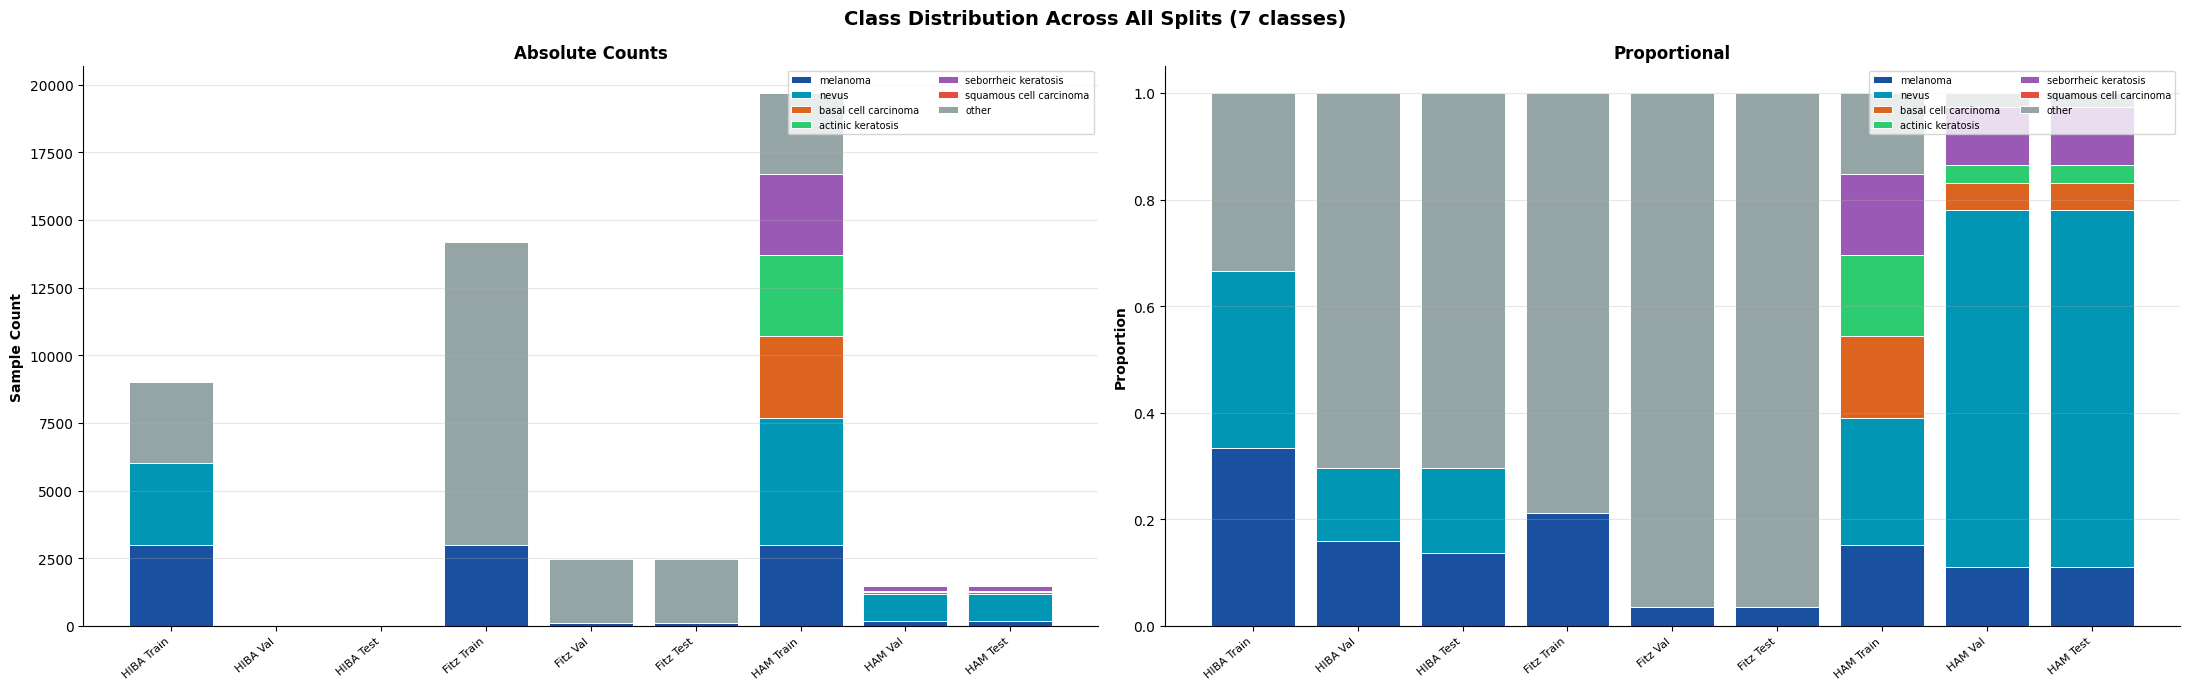

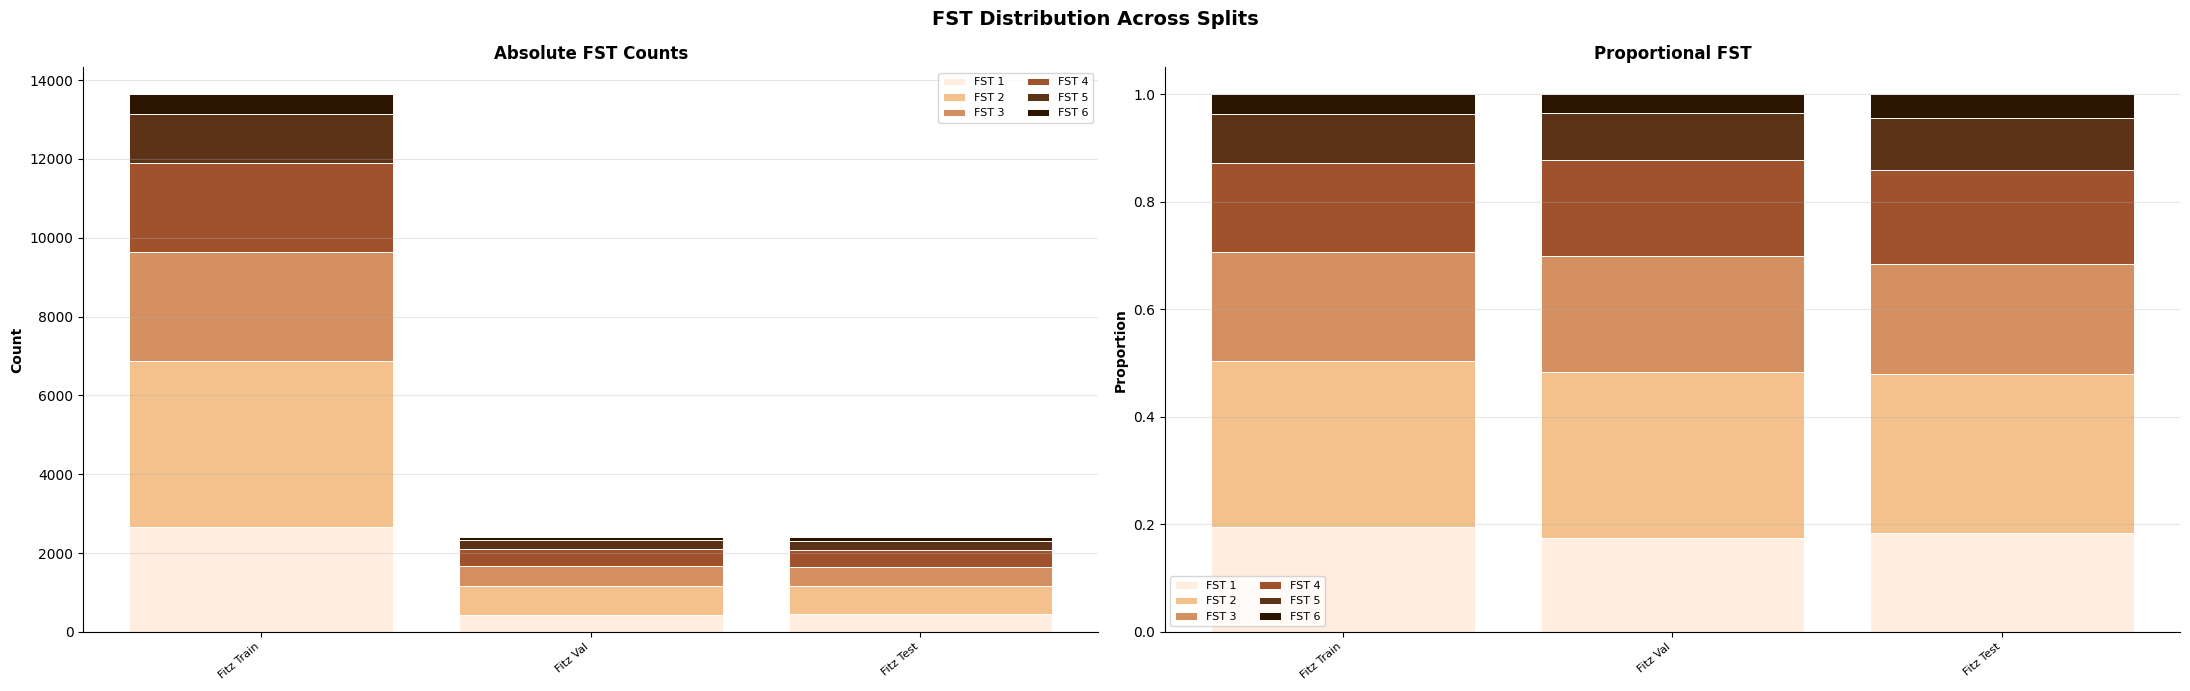

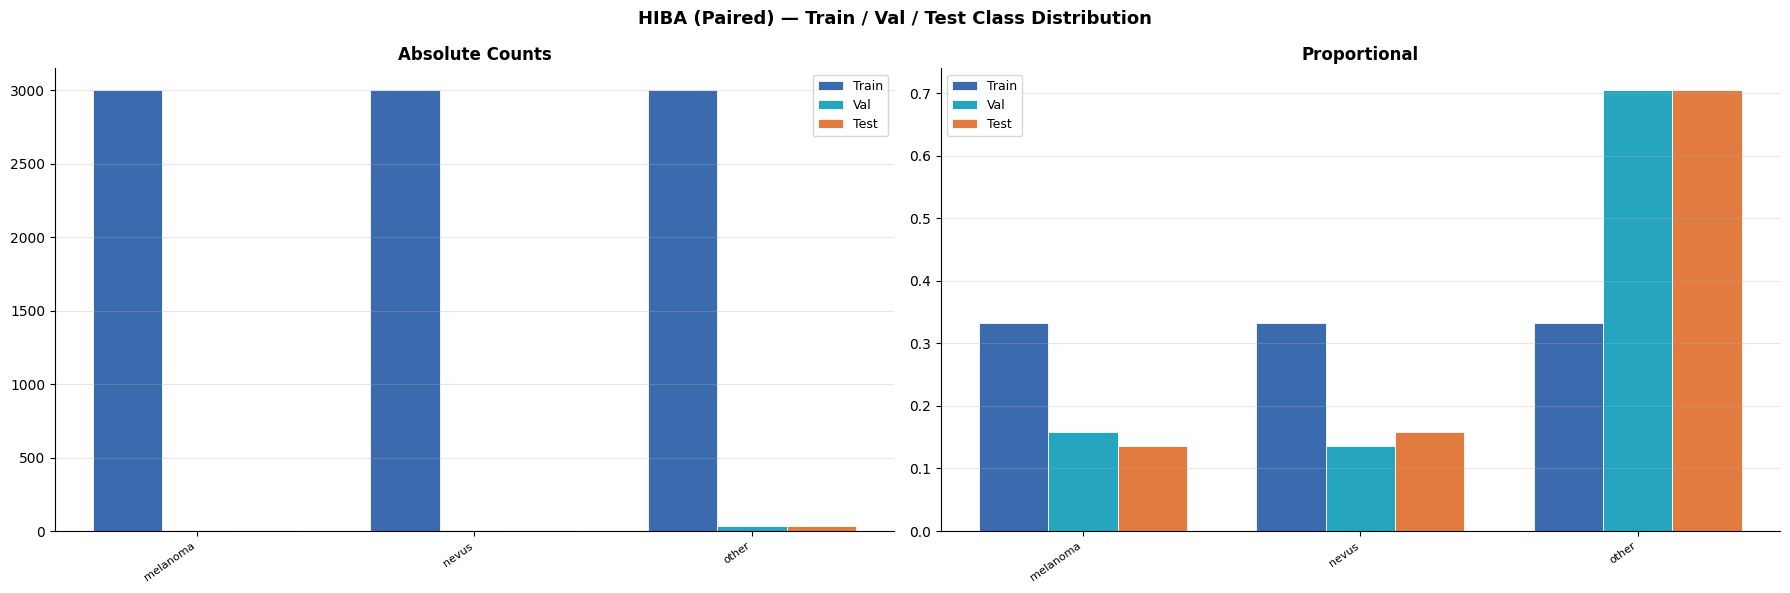

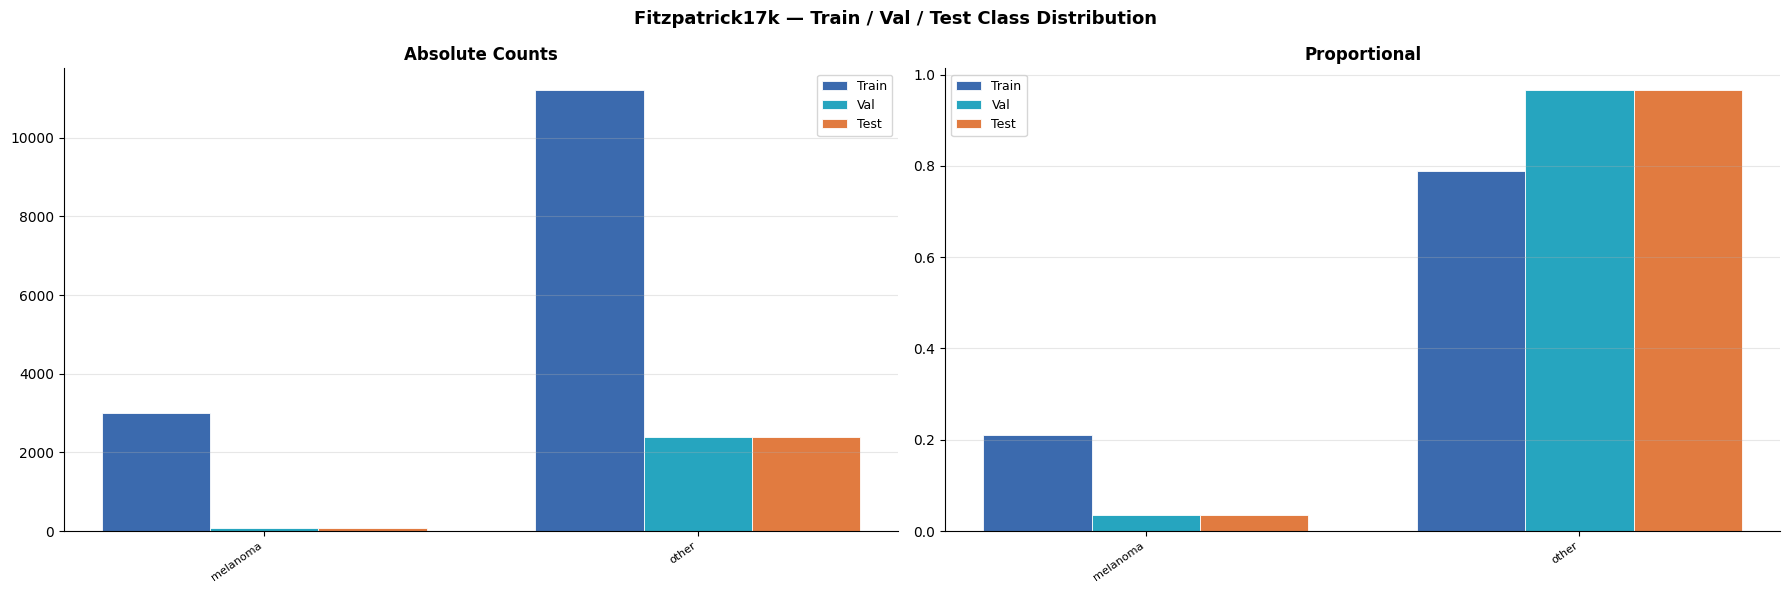

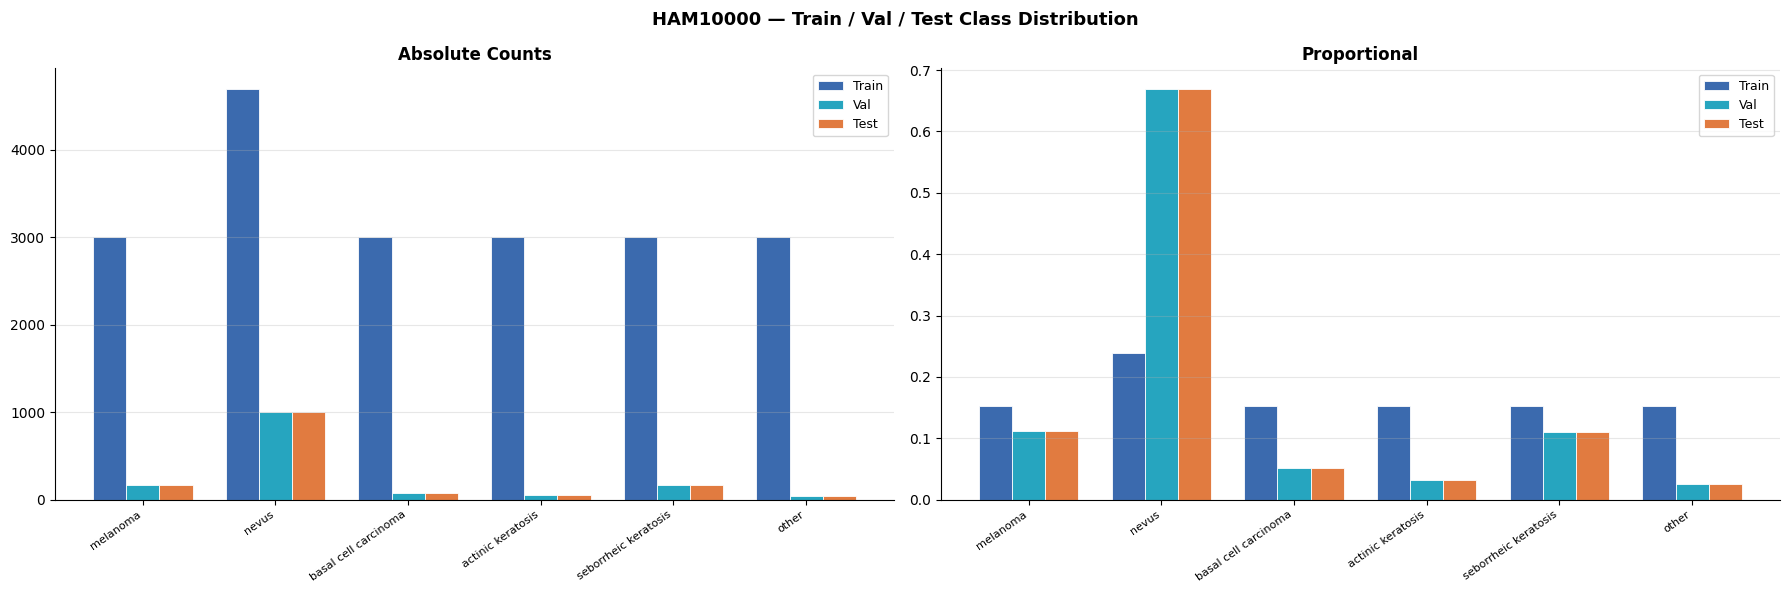

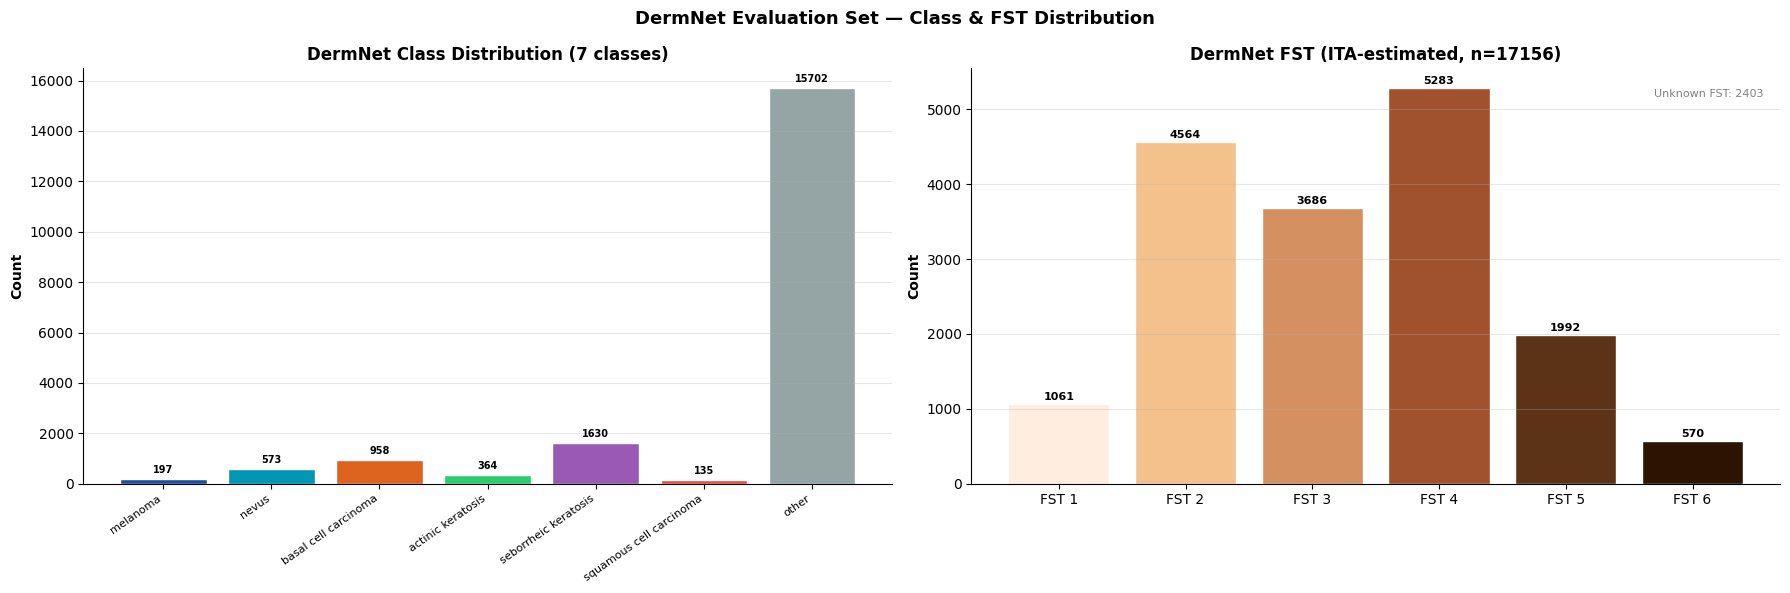

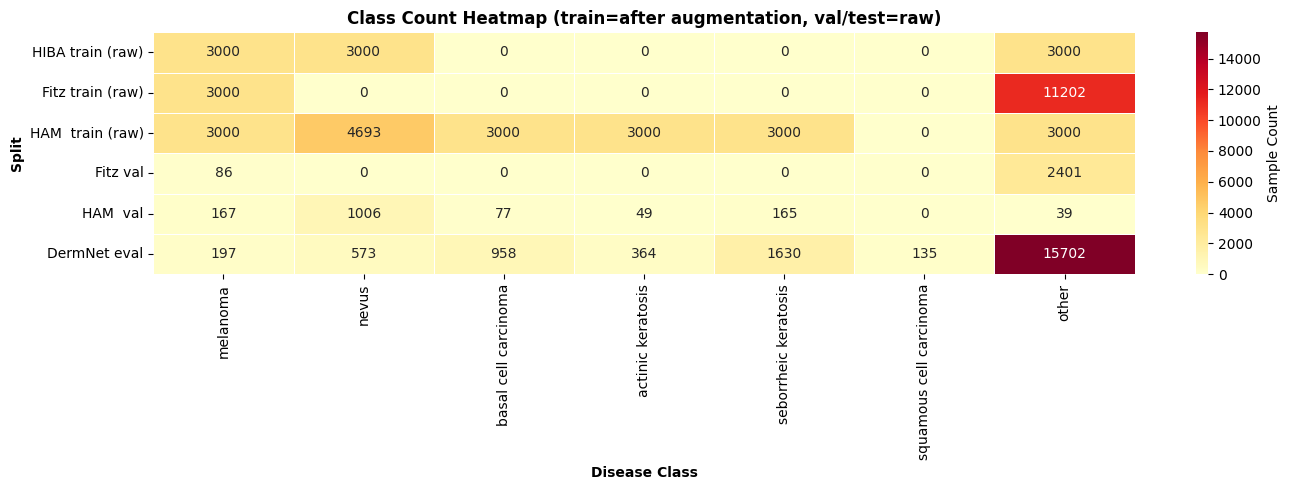


── Coverage Summary ─────────────────────────────────────
                Total rows  FST known  FST %  Class=Other Other %
Dataset                                                          
HIBA                  9000          0   0.0%         3000   33.3%
Fitzpatrick17k       14202      13640  96.0%        11202   78.9%
HAM10000             19693          0   0.0%         3000   15.2%
DermNet              19559      17156  87.7%        15702   80.3%

EDA visualizations saved.


In [11]:
# ════════════════════════════════════════════════════════════════════════════
# EDA — DATASET DISTRIBUTION VISUALIZATIONS  (7 classes)
# ════════════════════════════════════════════════════════════════════════════
import warnings as _w; _w.filterwarnings('ignore')

_LN  = LABEL_NAMES                          # {0:'melanoma', …, 6:'other'}
_LBL = [_LN[i] for i in range(7)]           # ordered list
_FST = {i: f'FST {i+1}' for i in range(6)}

_PAL_CLS = ['#1950A0','#0096B4','#DC641E','#2ECC71','#9B59B6','#E74C3C','#95A5A6']
_PAL_FST = ['#FFEDE0','#F4C18C','#D49060','#A0522D','#5C3317','#2B1500']

csv_dir = CFG['csv_dir']
def _load(fname):
    p = csv_dir / fname
    return pd.read_csv(p) if p.exists() else pd.DataFrame()

# ── Load all splits ───────────────────────────────────────────────────────
_splits = {}
for tag, fname in [
    ('HIBA Train', 'paired_train.csv'), ('HIBA Val', 'paired_val.csv'),   ('HIBA Test', 'paired_test.csv'),
    ('Fitz Train', 'clin_train.csv'),   ('Fitz Val', 'clin_val.csv'),     ('Fitz Test', 'clin_test.csv'),
    ('HAM Train',  'derm_train.csv'),   ('HAM Val',  'derm_val.csv'),     ('HAM Test',  'derm_test.csv'),
]:
    d = _load(fname)
    if d.empty: continue
    # normalise clinical_path → image_path for paired sets
    if 'image_path' not in d.columns and 'clinical_path' in d.columns:
        d = d.rename(columns={'clinical_path': 'image_path'})
    _splits[tag] = d

_dermnet = _load('eval_dermnet.csv')

# ──────────────────────────────────────────────────────────────────────────
# FIG 1  Class distribution across ALL splits (stacked absolute + proportional)
# ──────────────────────────────────────────────────────────────────────────
if _splits:
    _snames = list(_splits.keys())
    fig, axes = plt.subplots(1, 2, figsize=(22, 7))
    fig.suptitle('Class Distribution Across All Splits (7 classes)', fontsize=14, fontweight='bold')
    x = np.arange(len(_snames))
    bot_abs = np.zeros(len(_snames))
    bot_prop = np.zeros(len(_snames))
    totals = np.array([len(_splits[s]) for s in _snames], dtype=float)
    for ci in range(7):
        vals = np.array([_splits[s]['label'].value_counts().get(ci, 0) for s in _snames])
        axes[0].bar(x, vals, bottom=bot_abs,  color=_PAL_CLS[ci], label=_LBL[ci], edgecolor='white', lw=0.7)
        axes[1].bar(x, vals/np.maximum(totals,1), bottom=bot_prop, color=_PAL_CLS[ci], label=_LBL[ci], edgecolor='white', lw=0.7)
        bot_abs  += vals
        bot_prop += vals/np.maximum(totals,1)
    for ax, title, ylabel in [
        (axes[0], 'Absolute Counts', 'Sample Count'),
        (axes[1], 'Proportional',    'Proportion'),
    ]:
        ax.set_xticks(x); ax.set_xticklabels(_snames, rotation=40, ha='right', fontsize=8)
        ax.set_title(title, fontweight='bold'); ax.set_ylabel(ylabel, fontweight='bold')
        ax.legend(fontsize=7, ncol=2, loc='upper right')
        ax.grid(axis='y', alpha=0.3); ax.spines[['top','right']].set_visible(False)
    axes[1].set_ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(CFG['results_dir']/'eda_class_all_splits.png', dpi=150, bbox_inches='tight')
    plt.show()

# ──────────────────────────────────────────────────────────────────────────
# FIG 2  FST distribution (only splits with FST annotations)
# ──────────────────────────────────────────────────────────────────────────
_fst_splits = {s: d for s, d in _splits.items()
               if 'skin_type' in d.columns and (d['skin_type'] >= 0).any()}
if _fst_splits:
    _fs = list(_fst_splits.keys())
    fig, axes = plt.subplots(1, 2, figsize=(22, 7))
    fig.suptitle('FST Distribution Across Splits', fontsize=14, fontweight='bold')
    x = np.arange(len(_fs))
    bot_abs = np.zeros(len(_fs)); bot_prop = np.zeros(len(_fs))
    for fi in range(6):
        vals  = np.array([(d['skin_type'] == fi).sum() for d in _fst_splits.values()])
        known = np.array([(d['skin_type'] >= 0).sum() for d in _fst_splits.values()], dtype=float)
        axes[0].bar(x, vals, bottom=bot_abs,  color=_PAL_FST[fi], label=_FST[fi], edgecolor='white', lw=0.7)
        axes[1].bar(x, vals/np.maximum(known,1), bottom=bot_prop, color=_PAL_FST[fi], label=_FST[fi], edgecolor='white', lw=0.7)
        bot_abs  += vals
        bot_prop += vals/np.maximum(known,1)
    for ax, title, ylabel in [
        (axes[0], 'Absolute FST Counts', 'Count'),
        (axes[1], 'Proportional FST',    'Proportion'),
    ]:
        ax.set_xticks(x); ax.set_xticklabels(_fs, rotation=40, ha='right', fontsize=8)
        ax.set_title(title, fontweight='bold'); ax.set_ylabel(ylabel, fontweight='bold')
        ax.legend(fontsize=8, ncol=2); ax.grid(axis='y', alpha=0.3)
        ax.spines[['top','right']].set_visible(False)
    axes[1].set_ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(CFG['results_dir']/'eda_fst_all_splits.png', dpi=150, bbox_inches='tight')
    plt.show()

# ──────────────────────────────────────────────────────────────────────────
# FIG 3  Per-dataset train/val/test grouped bar (class counts)
# ──────────────────────────────────────────────────────────────────────────
for ds_name, prefix, cols in [
    ('HIBA (Paired)',  'HIBA', ['HIBA Train','HIBA Val','HIBA Test']),
    ('Fitzpatrick17k', 'Fitz', ['Fitz Train','Fitz Val','Fitz Test']),
    ('HAM10000',       'HAM',  ['HAM Train', 'HAM Val', 'HAM Test']),
]:
    dfs = {c: _splits[c] for c in cols if c in _splits}
    if not dfs: continue
    present_cls = sorted(set(c for d in dfs.values() for c in d['label'].unique()))
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f'{ds_name} — Train / Val / Test Class Distribution', fontsize=13, fontweight='bold')
    split_labels = list(dfs.keys())
    x = np.arange(len(present_cls)); w = 0.25
    colors = ['#1950A0','#0096B4','#DC641E']
    for si, (sname, d) in enumerate(dfs.items()):
        cnts = [d['label'].value_counts().get(c, 0) for c in present_cls]
        axes[0].bar(x+(si-1)*w, cnts, w, label=sname.replace(prefix+' ',''),
                    color=colors[si], edgecolor='white', lw=0.7, alpha=0.85)
        props = np.array(cnts, dtype=float)/max(sum(cnts),1)
        axes[1].bar(x+(si-1)*w, props, w, label=sname.replace(prefix+' ',''),
                    color=colors[si], edgecolor='white', lw=0.7, alpha=0.85)
    for ax, title in [(axes[0],'Absolute Counts'),(axes[1],'Proportional')]:
        ax.set_xticks(x); ax.set_xticklabels([_LN.get(c,f'C{c}') for c in present_cls],
                                               rotation=35, ha='right', fontsize=8)
        ax.set_title(title, fontweight='bold'); ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.3); ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(CFG['results_dir']/f'eda_class_{prefix.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

# ──────────────────────────────────────────────────────────────────────────
# FIG 4  DermNet class + FST (eval set)
# ──────────────────────────────────────────────────────────────────────────
if not _dermnet.empty:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('DermNet Evaluation Set — Class & FST Distribution', fontsize=13, fontweight='bold')
    vc = _dermnet['label'].value_counts().sort_index()
    bar_cols = [_PAL_CLS[i % 7] for i in vc.index]
    bars = axes[0].bar([_LN.get(i,f'C{i}') for i in vc.index], vc.values,
                       color=bar_cols, edgecolor='white', lw=1)
    for b, n in zip(bars, vc.values):
        axes[0].text(b.get_x()+b.get_width()/2, n+vc.values.max()*0.01, str(n),
                     ha='center', va='bottom', fontsize=7, fontweight='bold')
    axes[0].set_title('DermNet Class Distribution (7 classes)', fontweight='bold')
    axes[0].set_xticklabels([_LN.get(i,f'C{i}') for i in vc.index], rotation=35, ha='right', fontsize=8)
    axes[0].set_ylabel('Count', fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3); axes[0].spines[['top','right']].set_visible(False)
    if 'skin_type' in _dermnet.columns:
        fst_k = _dermnet[_dermnet['skin_type'] >= 0]
        if not fst_k.empty:
            fst_ns = [(_dermnet['skin_type']==fi).sum() for fi in range(6)]
            b2 = axes[1].bar([_FST[fi] for fi in range(6)], fst_ns, color=_PAL_FST, edgecolor='white', lw=1)
            for bar, n in zip(b2, fst_ns):
                if n: axes[1].text(bar.get_x()+bar.get_width()/2, n+max(fst_ns)*0.01,
                                   str(n), ha='center', fontsize=8, fontweight='bold')
            axes[1].set_title(f'DermNet FST (ITA-estimated, n={len(fst_k)})', fontweight='bold')
            axes[1].set_ylabel('Count', fontweight='bold')
            axes[1].text(0.98, 0.95, f'Unknown FST: {(_dermnet["skin_type"]<0).sum()}',
                         transform=axes[1].transAxes, ha='right', va='top', fontsize=8, color='grey')
            axes[1].grid(axis='y', alpha=0.3); axes[1].spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(CFG['results_dir']/'eda_dermnet.png', dpi=150, bbox_inches='tight')
    plt.show()

# ──────────────────────────────────────────────────────────────────────────
# FIG 5  Class imbalance heatmap — raw counts per (dataset × class)
# ──────────────────────────────────────────────────────────────────────────
_heatmap_splits = {
    'HIBA train (raw)':  pd.read_csv(csv_dir/'paired_train.csv') if (csv_dir/'paired_train.csv').exists() else pd.DataFrame(),
    'Fitz train (raw)':  pd.read_csv(csv_dir/'clin_train.csv')   if (csv_dir/'clin_train.csv').exists()   else pd.DataFrame(),
    'HAM  train (raw)':  pd.read_csv(csv_dir/'derm_train.csv')   if (csv_dir/'derm_train.csv').exists()   else pd.DataFrame(),
    'Fitz val':          pd.read_csv(csv_dir/'clin_val.csv')      if (csv_dir/'clin_val.csv').exists()      else pd.DataFrame(),
    'HAM  val':          pd.read_csv(csv_dir/'derm_val.csv')      if (csv_dir/'derm_val.csv').exists()      else pd.DataFrame(),
    'DermNet eval':      _dermnet,
}
_hmap_data = {}
for name, d in _heatmap_splits.items():
    if d.empty: continue
    _hmap_data[name] = [d['label'].value_counts().get(ci, 0) for ci in range(7)]
if _hmap_data:
    import seaborn as sns
    _hm_df = pd.DataFrame(_hmap_data, index=[_LN[i] for i in range(7)]).T
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.heatmap(_hm_df, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5,
                linecolor='white', ax=ax, cbar_kws={'label': 'Sample Count'})
    ax.set_title('Class Count Heatmap (train=after augmentation, val/test=raw)',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Disease Class', fontweight='bold')
    ax.set_ylabel('Split', fontweight='bold')
    plt.tight_layout()
    plt.savefig(CFG['results_dir']/'eda_imbalance_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

# ──────────────────────────────────────────────────────────────────────────
# FIG 6  Coverage summary: % images found + % FST known per dataset
# ──────────────────────────────────────────────────────────────────────────
_cov_rows = []
for tag, fname in [('HIBA','paired_train.csv'),('Fitzpatrick17k','clin_train.csv'),
                    ('HAM10000','derm_train.csv'),('DermNet','eval_dermnet.csv')]:
    d = _load(fname)
    if d.empty: continue
    _img_col = 'image_path' if 'image_path' in d.columns else 'clinical_path'
    n_total  = len(d)
    n_fst    = int((d['skin_type'] >= 0).sum()) if 'skin_type' in d.columns else 0
    n_cls6   = int((d['label'] == 6).sum()) if 'label' in d.columns else 0
    _cov_rows.append({'Dataset': tag, 'Total rows': n_total,
                       'FST known': n_fst, 'FST %': f'{100*n_fst/max(n_total,1):.1f}%',
                       'Class=Other': n_cls6, 'Other %': f'{100*n_cls6/max(n_total,1):.1f}%'})
if _cov_rows:
    _cov_df = pd.DataFrame(_cov_rows).set_index('Dataset')
    print('\n── Coverage Summary ─────────────────────────────────────')
    print(_cov_df.to_string())
    _cov_df.to_csv(CFG['results_dir']/'eda_coverage_summary.csv')

print('\nEDA visualizations saved.')


In [12]:
# ════════════════════════════════════════════════════════════════════════════
# TRANSFORMS  &  DATASET CLASSES
# ════════════════════════════════════════════════════════════════════════════
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD  = [0.229, 0.224, 0.225]

train_tfm = transforms.Compose([
    transforms.Resize((CFG['img_size']+32, CFG['img_size']+32)),
    transforms.RandomCrop(CFG['img_size']),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomApply([transforms.RandomRotation(30)], p=0.7),
    transforms.RandomApply([transforms.ColorJitter(
        brightness=0.3, contrast=0.3, saturation=0.2, hue=0.08)], p=0.8),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))], p=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.85, 1.15)),
    transforms.RandomAutocontrast(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(IMG_MEAN, IMG_STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),  # simulate occlusion artefacts
])
val_tfm = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.ToTensor(), transforms.Normalize(IMG_MEAN, IMG_STD),
])
denorm_tfm = transforms.Compose([
    transforms.Normalize(mean=[0,0,0], std=[1/s for s in IMG_STD]),
    transforms.Normalize(mean=[-m for m in IMG_MEAN], std=[1,1,1]),
])


class UnpairedSkinDataset(Dataset):
    def __init__(self, df_or_csv, modality='clinical', transform=None):
        self.df = (pd.read_csv(df_or_csv) if isinstance(df_or_csv,(str,Path))
                   else df_or_csv.reset_index(drop=True))
        self.modality = modality; self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        try: img = Image.open(r['image_path']).convert('RGB')
        except: img = Image.new('RGB',(224,224))
        if self.transform: img = self.transform(img)
        return {'image':img,
                'label'    :torch.tensor(int(r['label']),    dtype=torch.long),
                'skin_type':torch.tensor(int(r['skin_type']),dtype=torch.long),
                'modality' :self.modality, 'paired':False,
                'image_path': str(r['image_path'])}


class PairedSkinDataset(Dataset):
    def __init__(self, df_or_csv, transform=None):
        self.df = (pd.read_csv(df_or_csv) if isinstance(df_or_csv,(str,Path))
                   else df_or_csv.reset_index(drop=True))
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        try:
            clin = Image.open(r['clinical_path']).convert('RGB')
            derm = Image.open(r['derm_path']).convert('RGB')
        except:
            clin = derm = Image.new('RGB',(224,224))
        if self.transform: clin=self.transform(clin); derm=self.transform(derm)
        return {'clinical':clin,'derm':derm,
                'label'    :torch.tensor(int(r['label']),    dtype=torch.long),
                'skin_type':torch.tensor(int(r['skin_type']),dtype=torch.long),
                'paired':True}


class MixedDataset(Dataset):
    def __init__(self, paired_ds, unpaired_list):
        self.paired   = paired_ds
        self.unpaired = unpaired_list
        self.index = (
            [('p',i)     for i in range(len(paired_ds))] +
            [('u',di,i)  for di,ds in enumerate(unpaired_list)
                         for i in range(len(ds))]
        )
    def __len__(self): return len(self.index)
    def __getitem__(self, i):
        e = self.index[i]
        return self.paired[e[1]] if e[0]=='p' else self.unpaired[e[1]][e[2]]


def mixed_collate(batch):
    """FIX: separate paired vs unpaired items, stack each pool independently,
    so that 'clinical'/'derm' tensors contain ONLY paired rows and
    'image' contains ONLY unpaired rows — matching the boolean masks in forward().
    """
    paired_items   = [item for item in batch if item.get('paired') is True]
    unpaired_items = [item for item in batch if item.get('paired') is not True]

    result = {}

    # Always include these for every sample
    all_labels    = [item['label']     for item in batch]
    all_skins     = [item['skin_type'] for item in batch]
    all_paired    = [item['paired']    for item in batch]
    all_modality  = [item.get('modality', 'clinical') for item in batch]
    all_imgpath   = [item.get('image_path', '') for item in batch]

    result['label']      = torch.stack(all_labels)
    result['skin_type']  = torch.stack(all_skins)
    result['paired']     = all_paired
    result['modality']   = all_modality
    result['image_path'] = all_imgpath

    # Stack paired images (only rows that are paired)
    if paired_items:
        result['clinical'] = torch.stack([item['clinical'] for item in paired_items])
        result['derm']     = torch.stack([item['derm']     for item in paired_items])

    # Stack unpaired images (only rows that are unpaired)
    if unpaired_items:
        result['image'] = torch.stack([item['image'] for item in unpaired_items])

    return result

print('Transforms and Dataset classes defined.')


Transforms and Dataset classes defined.


In [13]:
# ════════════════════════════════════════════════════════════════════════════
# BUILD DATA LOADERS
# (guards added: if a CSV is absent or empty, fall back to an empty dataset)
# ════════════════════════════════════════════════════════════════════════════
import pandas as _pd
from torch.utils.data import WeightedRandomSampler

def _safe_csv(path):
    """Return a DataFrame from the CSV if it exists and is non-empty, else empty DF."""
    p = Path(path)
    if not p.exists():
        print(f'  [WARN] CSV not found, skipping: {p.name}')
        return _pd.DataFrame()
    df = _pd.read_csv(p)
    if df.empty:
        print(f'  [WARN] CSV is empty, skipping: {p.name}')
    return df

csv = CFG['csv_dir']

# Paired (HIBA)
_paired_tr = _safe_csv(csv/'paired_train.csv')
_paired_va = _safe_csv(csv/'paired_val.csv')
paired_tr_ds = PairedSkinDataset(_paired_tr, train_tfm) if not _paired_tr.empty else None
paired_va_ds = PairedSkinDataset(_paired_va, val_tfm)   if not _paired_va.empty else None

# Clinical unpaired (Fitzpatrick17k)
_clin_tr = _safe_csv(csv/'clin_train.csv')
_clin_va = _safe_csv(csv/'clin_val.csv')
clin_tr_ds  = UnpairedSkinDataset(_clin_tr, 'clinical', train_tfm) if not _clin_tr.empty else None
clin_val_ds = UnpairedSkinDataset(_clin_va, 'clinical', val_tfm)   if not _clin_va.empty else None

# Dermoscopic unpaired (HAM10000)
_derm_tr = _safe_csv(csv/'derm_train.csv')
derm_tr_ds = UnpairedSkinDataset(_derm_tr, 'derm', train_tfm) if not _derm_tr.empty else None

# Build mixed training dataset — require at least one unpaired source
_unpaired_list = [ds for ds in [clin_tr_ds, derm_tr_ds] if ds is not None]
assert _unpaired_list or paired_tr_ds is not None, \
    'No training data found — check that dataset CSVs were built in Phase 1.'

if paired_tr_ds is None:
    class _EmptyPaired(Dataset):
        def __len__(self): return 0
        def __getitem__(self, i): raise IndexError
    paired_tr_ds = _EmptyPaired()

if not _unpaired_list:
    _unpaired_list = []

train_ds = MixedDataset(paired_tr_ds, _unpaired_list)


# ── FIX: WeightedRandomSampler with FAST label extraction ────────────────
# OLD CODE was calling dataset[idx] (i.e. __getitem__) for every sample,
# which opened every image file just to read the label — extremely slow.
# Instead, we extract labels directly from the underlying DataFrames,
# which is an O(N) in-memory operation and completes in milliseconds.

def _build_sampler_fast(paired_ds, unpaired_ds_list, paired_df, unpaired_dfs):
    """Build WeightedRandomSampler from DataFrames — no image I/O needed.

    The MixedDataset index is:
        [('p', i) for i in range(len(paired_ds))]
      + [('u', di, i) for di, ds in enumerate(unpaired_list) for i in range(len(ds))]

    We replicate that order using the source DataFrames directly.
    """
    all_labels = []

    # Paired labels — use 'label' column from the paired DataFrame
    if paired_df is not None and not paired_df.empty:
        all_labels.extend(paired_df['label'].astype(int).tolist())

    # Unpaired labels — concatenate label columns from each unpaired DataFrame
    for df in unpaired_dfs:
        if df is not None and not df.empty:
            all_labels.extend(df['label'].astype(int).tolist())

    all_labels = np.array(all_labels)
    class_counts = np.bincount(all_labels, minlength=CFG['num_classes']).astype(float)
    class_counts = np.where(class_counts == 0, 1, class_counts)   # avoid /0
    weights = 1.0 / class_counts[all_labels]
    return WeightedRandomSampler(
        weights=torch.from_numpy(weights).double(),
        num_samples=len(weights),
        replacement=True
    )

print('  Building WeightedRandomSampler (reading from DataFrames — no image I/O) ...')

# Collect the source DataFrames in the same order MixedDataset uses them
_paired_df_for_sampler   = _paired_tr if not _paired_tr.empty else None
_unpaired_dfs_for_sampler = [
    df for df in [_clin_tr, _derm_tr]
    if df is not None and not df.empty
]

_sampler = _build_sampler_fast(
    paired_tr_ds,
    _unpaired_list,
    _paired_df_for_sampler,
    _unpaired_dfs_for_sampler,
)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG['batch_size'],
    sampler=_sampler,              # replaces shuffle=True
    collate_fn=mixed_collate,
    num_workers=4,
    pin_memory=True,
    drop_last=True,
    persistent_workers=True,       # avoids re-spawning workers each epoch
    prefetch_factor=2,             # prefetch 2 batches per worker
)

# Validation loader — combine clinical AND dermoscopic val sets
_val_parts = []
if clin_val_ds is not None:
    _val_parts.append(clin_val_ds)
_derm_va = _safe_csv(csv/'derm_val.csv')
if not _derm_va.empty:
    _val_parts.append(UnpairedSkinDataset(_derm_va, 'derm', val_tfm))
assert _val_parts, 'No validation data found.'
from torch.utils.data import ConcatDataset as _ConcatDSval
_val_ds = _ConcatDSval(_val_parts) if len(_val_parts) > 1 else _val_parts[0]

val_loader = DataLoader(
    _val_ds,
    batch_size=CFG['batch_size'] * 2,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    collate_fn=mixed_collate,
    persistent_workers=True,
    prefetch_factor=2,
)

# ── Internal Test loader (held-out 20 %) ──────────────────────────────────
_test_dfs = []
for _csv_f, _mod in [
        (csv/'paired_test.csv',  'clinical'),
        (csv/'clin_test.csv',    'clinical'),
        (csv/'derm_test.csv',    'derm'),
]:
    _d = _safe_csv(_csv_f)
    if not _d.empty:
        _test_dfs.append((_d, _mod))

if _test_dfs:
    _combined_test_dfs = []
    for _d, _mod in _test_dfs:
        if 'image_path' not in _d.columns and 'clinical_path' in _d.columns:
            _d = _d.rename(columns={'clinical_path': 'image_path'})
        _combined_test_dfs.append(UnpairedSkinDataset(_d, _mod, val_tfm))
    from torch.utils.data import ConcatDataset as _ConcatDS
    _test_combined = _ConcatDS(_combined_test_dfs)
    test_loader = DataLoader(
        _test_combined,
        batch_size=CFG['batch_size'] * 2,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        collate_fn=mixed_collate,
        persistent_workers=True,
        prefetch_factor=2,
    )
    print(f'  internal test set: {len(_test_combined)} samples')
else:
    test_loader = None
    print('  [WARN] No internal test CSVs found — test_loader is None')

# Evaluation loaders
eval_loaders = {}
for ds_name, (csv_f, modality) in {
        'dermnet': (csv/'eval_dermnet.csv', 'clinical'),
}.items():
    if not csv_f.exists():
        continue
    _eval_df = _safe_csv(csv_f)
    if _eval_df.empty:
        continue
    ds = UnpairedSkinDataset(_eval_df, modality, val_tfm)
    eval_loaders[ds_name] = DataLoader(
        ds,
        batch_size=CFG['batch_size'] * 2,
        shuffle=False,
        num_workers=4,
        collate_fn=mixed_collate,
        persistent_workers=True,
        prefetch_factor=2,
    )
    print(f'  eval [{ds_name}]: {len(ds)} samples')

print(f'\nTrain batches : {len(train_loader)}  |  Val batches: {len(val_loader)}')
print(f'Eval sets      : {list(eval_loaders.keys())}')

  Building WeightedRandomSampler (reading from DataFrames — no image I/O) ...
  internal test set: 4034 samples
  eval [dermnet]: 19559 samples

Train batches : 1340  |  Val batches: 63
Eval sets      : ['dermnet']


## Phase 2 — Model Architecture

In [14]:
# ════════════════════════════════════════════════════════════════════════════
# DUAL-ENCODER MODEL
# ════════════════════════════════════════════════════════════════════════════

def _load_backbone(backbone_name: str, pretrained: bool = True):
    """Load a timm backbone, downloading weights at most once per session.

    timm respects TORCH_HOME for its cache, so after the first call the
    weights live in /kaggle/working/backbone_cache and are reused directly
    without any network traffic.  This prevents the double-download that
    occurred when both clinical_enc and derm_enc each called
    timm.create_model(..., pretrained=True) independently.
    """
    return timm.create_model(backbone_name, pretrained=pretrained, num_classes=0)


class ProjectionHead(nn.Module):
    def __init__(self, in_dim, hidden_dim=1024, out_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.BatchNorm1d(hidden_dim),
            nn.GELU(), nn.Linear(hidden_dim, out_dim))
    def forward(self, x):
        # BatchNorm1d crashes on batch_size=1 in training mode (no variance).
        # Switch to eval (uses running stats) for single-sample forward passes.
        if x.size(0) == 1 and self.training:
            self.eval()
            output = self.net(x)
            self.train()
        else:
            output = self.net(x)
        return F.normalize(output, dim=-1)


class ModalityEncoder(nn.Module):
    def __init__(self, backbone_name, proj_head, pretrained=True):
        super().__init__()
        self.backbone = _load_backbone(backbone_name, pretrained)
        self.proj = proj_head
    def forward(self, x):
        f = self.backbone(x); return f, self.proj(f)


class DualEncoderModel(nn.Module):
    def __init__(self, backbone_name, embed_dim, num_classes,
                 num_skin_types, pretrained=True):
        super().__init__()
        # Probe backbone feature dimension without downloading weights
        _t       = timm.create_model(backbone_name, pretrained=False, num_classes=0)
        feat_dim = _t.num_features; del _t

        self.proj_head    = ProjectionHead(feat_dim, 1024, embed_dim)

        # Download weights once for clinical encoder.
        # timm caches to TORCH_HOME after the first download, so the derm
        # encoder instantiation below is served from disk — no second download.
        self.clinical_enc = ModalityEncoder(backbone_name, self.proj_head, pretrained)
        self.derm_enc     = ModalityEncoder(backbone_name, self.proj_head, pretrained)

        self.classifier   = nn.Linear(embed_dim, num_classes)
        self.skin_clf     = nn.Sequential(
            nn.Linear(embed_dim, 256), nn.ReLU(), nn.Linear(256, num_skin_types))
        total = sum(p.numel() for p in self.parameters()) / 1e6
        print(f'DualEncoderModel  backbone={backbone_name}  '
              f'feat={feat_dim}  embed={embed_dim}  params={total:.1f}M')

    def encode(self, x, modality):
        return self.clinical_enc(x) if modality == 'clinical' else self.derm_enc(x)

    def forward(self, batch):
        """FIX: after mixed_collate fix, batch['clinical']/batch['derm'] contain
        exactly the paired sub-batch rows and batch['image'] contains exactly
        the unpaired sub-batch rows. We fill embeddings_full using boolean masks
        derived from the paired flags, which now correctly line up.
        """
        out = {}
        batch_size   = len(batch['label'])
        embed_dim    = self.proj_head.net[-1].out_features
        embeddings_full = torch.zeros(batch_size, embed_dim, device=batch['label'].device)

        is_paired_flags = batch['paired']
        paired_mask  = torch.tensor(is_paired_flags, dtype=torch.bool,
                                    device=batch['label'].device)
        unpaired_mask = ~paired_mask

        # ── Paired branch ──────────────────────────────────────────────────
        if paired_mask.any() and 'clinical' in batch and 'derm' in batch:
            clin_t = batch['clinical'].to(batch['label'].device)
            derm_t = batch['derm'].to(batch['label'].device)
            _, z_c = self.clinical_enc(clin_t)
            _, z_d = self.derm_enc(derm_t)
            z_paired = (z_c + z_d) / 2
            embeddings_full[paired_mask] = z_paired
            out['z_c'] = z_c
            out['z_d'] = z_d

        # ── Unpaired branch ────────────────────────────────────────────────
        if unpaired_mask.any() and 'image' in batch:
            img_t = batch['image'].to(batch['label'].device)
            modality = 'clinical'
            for i, is_p in enumerate(is_paired_flags):
                if not is_p:
                    modality = batch['modality'][i]
                    break
            _, z_unpaired = self.encode(img_t, modality)
            embeddings_full[unpaired_mask] = z_unpaired

        out['z']           = embeddings_full
        out['logits']      = self.classifier(out['z'])
        out['skin_logits'] = self.skin_clf(out['z'])
        return out

    def forward_image(self, x: torch.Tensor, modality: str = 'clinical'):
        """Single-tensor entry point for SHAP/Captum."""
        _, z = self.encode(x, modality)
        return self.classifier(z)


model = DualEncoderModel(
    backbone_name  = CFG['backbone'],
    embed_dim      = CFG['embed_dim'],
    num_classes    = CFG['num_classes'],
    num_skin_types = CFG['num_skin_types'],
    pretrained     = True,
).to(DEVICE)

# Smoke-test: all-paired batch
with torch.no_grad():
    _t = model({'clinical'  : torch.randn(2,3,224,224).to(DEVICE),
                'derm'      : torch.randn(2,3,224,224).to(DEVICE),
                'label'     : torch.zeros(2,dtype=torch.long).to(DEVICE),
                'skin_type' : torch.zeros(2,dtype=torch.long).to(DEVICE),
                'paired'    : [True,True]})
print('Paired  forward OK  — logits:', _t['logits'].shape)

# Smoke-test: all-unpaired batch (simulates val_loader)
with torch.no_grad():
    _t2 = model({'image'     : torch.randn(2,3,224,224).to(DEVICE),
                 'label'     : torch.zeros(2,dtype=torch.long).to(DEVICE),
                 'skin_type' : torch.zeros(2,dtype=torch.long).to(DEVICE),
                 'paired'    : [False,False],
                 'modality'  : ['clinical','clinical']})
print('Unpaired forward OK — logits:', _t2['logits'].shape)

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

DualEncoderModel  backbone=vit_small_patch16_224  feat=384  embed=512  params=44.4M
Paired  forward OK  — logits: torch.Size([2, 7])
Unpaired forward OK — logits: torch.Size([2, 7])


## Phase 3 — Loss Functions

In [15]:
class FocalLoss(nn.Module):
    """Focal Loss (Lin et al. 2017) — down-weights easy examples.
    gamma=2 is the standard value; alpha=None means no per-class weighting
    (we rely on WeightedRandomSampler + augmentation for that).
    """
    def __init__(self, gamma=2.0, label_smoothing=0.05):
        super().__init__()
        self.gamma = gamma
        self.ls    = label_smoothing

    def forward(self, logits, targets):
        # Standard CE with label smoothing as base
        ce = F.cross_entropy(logits, targets, reduction='none',
                             label_smoothing=self.ls)
        pt = torch.exp(-ce)                   # probability of correct class
        return ((1 - pt) ** self.gamma * ce).mean()

cls_criterion = FocalLoss(gamma=2.0, label_smoothing=0.05)

def confusion_loss(skin_logits, K):
    B = skin_logits.size(0)
    uni = torch.full((B,K), 1./K, device=skin_logits.device)
    return F.kl_div(F.log_softmax(skin_logits,-1), uni, reduction='batchmean')

class SupConLoss(nn.Module):
    def __init__(self, T=0.07): super().__init__(); self.T=T
    def forward(self, z, labels):
        B=z.size(0)
        if B<2: return z.new_tensor(0.)
        sim = torch.mm(z,z.T)/self.T
        pos = (labels.unsqueeze(1)==labels.unsqueeze(0)); pos.fill_diagonal_(False)
        diag = ~torch.eye(B,dtype=torch.bool,device=z.device)
        has  = pos.sum(1)>0
        if not has.any(): return z.new_tensor(0.)
        logd = torch.log((torch.exp(sim)*diag).sum(1,keepdim=True)+1e-9)
        mp   = ((sim-logd)*pos).sum(1)/pos.sum(1).clamp(1)
        return -mp[has].mean()

def mi_loss(z_c, z_d): return F.mse_loss(z_c, z_d)   # L_MI — novel

sup_con = SupConLoss(CFG['temperature'])

def total_loss(out, batch, cfg):
    labels   = batch['label'].to(DEVICE)
    is_pair  = isinstance(batch.get('paired'),list) and any(batch['paired'])
    L = {}
    L['cls']  = cls_criterion(out['logits'], labels)
    tot       = cfg['lambda_cls']*L['cls']
    L['conf'] = confusion_loss(out['skin_logits'],cfg['num_skin_types']) \
                if cfg.get('use_conf') else out['logits'].new_tensor(0.)
    if cfg.get('use_conf'): tot += cfg['lambda_conf']*L['conf']
    L['con']  = sup_con(out['z'],labels) if cfg.get('use_con') \
                else out['logits'].new_tensor(0.)
    if cfg.get('use_con'): tot += cfg['lambda_con']*L['con']
    L['mi']   = (mi_loss(out['z_c'],out['z_d'])
                 if cfg.get('use_mi') and is_pair and 'z_c' in out
                 else out['logits'].new_tensor(0.))
    if cfg.get('use_mi') and is_pair and 'z_c' in out:
        tot  += cfg['lambda_mi']*L['mi']
    L['total'] = tot
    return L

print('Loss functions ready: FocalLoss | L_conf | L_con | L_MI')

Loss functions ready: FocalLoss | L_conf | L_con | L_MI


## Phase 4 — Training Loop

In [16]:
optimizer = torch.optim.AdamW(model.parameters(),
                              lr=CFG['lr'], weight_decay=CFG['weight_decay'])

def lr_lambda(ep):
    if ep < CFG['warmup_epochs']: return (ep+1)/CFG['warmup_epochs']
    p = (ep-CFG['warmup_epochs'])/max(1,CFG['num_epochs']-CFG['warmup_epochs'])
    return 0.5*(1+math.cos(math.pi*p))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def _safe_auroc(labels_1d, probs_nd):
    """Compute macro-OvR AUROC that works for 2, 3 … K present classes.

    sklearn's roc_auc_score(multi_class='ovr') requires y_score to be
    (N, K) with K >= 3.  When only 2 classes are present it raises:
      "y should be a 1d array, got an array of shape (N, 2) instead."
    Fix: for the binary case pass the positive-class column as a 1-D array.

    Args:
        labels_1d : (N,) integer array remapped to 0 … k-1
        probs_nd  : (N, k) renormalised probability columns for present classes
    Returns:
        float AUROC, or nan on failure
    """
    k = probs_nd.shape[1]
    try:
        if k == 2:
            # Binary: positive class is column 1
            return float(roc_auc_score(labels_1d, probs_nd[:, 1]))
        else:
            return float(roc_auc_score(labels_1d, probs_nd,
                                       multi_class='ovr', average='macro'))
    except Exception as e:
        print(f'  [AUROC=nan] {e}')
        return float('nan')


def train_epoch(model, loader, opt, cfg, ep):
    model.train()
    M, n = defaultdict(float), 0
    Pr, Pd, La, Sk = [], [], [], []
    for batch in tqdm(loader, desc=f'Train E{ep+1}', leave=False):
        for k,v in batch.items():
            if isinstance(v,torch.Tensor): batch[k]=v.to(DEVICE)
        opt.zero_grad()
        out = model(batch)
        L   = total_loss(out, batch, cfg)
        L['total'].backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        opt.step()
        for k,v in L.items():
            M[k] += v.item() if isinstance(v,torch.Tensor) else float(v)
        n += 1
        # Collect predictions for train metrics
        with torch.no_grad():
            prob = F.softmax(out['logits'], -1).cpu()
            Pr.append(prob); Pd.append(prob.argmax(-1))
            La.append(batch['label'].cpu()); Sk.append(batch['skin_type'].cpu())
    loss_dict = {k:v/n for k,v in M.items()}

    # Compute train classification metrics
    probs  = torch.cat(Pr).numpy()
    preds  = torch.cat(Pd).numpy()
    labels = torch.cat(La).numpy()
    skins  = torch.cat(Sk).numpy()
    acc = (preds == labels).mean()
    present = np.unique(labels)
    if len(present) >= 2:
        probs_sub  = probs[:, present]
        probs_norm = probs_sub / probs_sub.sum(axis=1, keepdims=True).clip(min=1e-9)
        lbl_map    = {c: i for i, c in enumerate(present)}
        labels_re  = np.array([lbl_map[l] for l in labels])
        auroc = _safe_auroc(labels_re, probs_norm)
    else:
        auroc = float('nan')
    f1 = f1_score(labels, preds, average='macro', zero_division=0)
    loss_dict['acc']      = acc
    loss_dict['auroc']    = auroc
    loss_dict['macro_f1'] = f1
    return loss_dict


@torch.no_grad()
def validate(model, loader):
    model.eval()
    Pr, Pd, La, Sk = [], [], [], []
    for batch in tqdm(loader, desc='Val', leave=False):
        for k,v in batch.items():
            if isinstance(v,torch.Tensor): batch[k]=v.to(DEVICE)
        out  = model(batch)
        prob = F.softmax(out['logits'], -1).cpu()
        Pr.append(prob); Pd.append(prob.argmax(-1))
        La.append(batch['label'].cpu()); Sk.append(batch['skin_type'].cpu())

    probs  = torch.cat(Pr).numpy()   # (N, 7)
    preds  = torch.cat(Pd).numpy()   # (N,)
    labels = torch.cat(La).numpy()   # (N,)  ← must be 1-D
    skins  = torch.cat(Sk).numpy()

    # Safety check — label tensor should always be 1-D after stacking scalars
    assert labels.ndim == 1, f'labels is {labels.shape}, expected 1-D'

    acc = (preds == labels).mean()

    present_classes = np.unique(labels)
    if len(present_classes) < 2:
        print(f'  [AUROC=nan] only {len(present_classes)} class(es) in val: {present_classes}')
        auroc = float('nan')
    else:
        # Subset columns to present classes and renormalise rows → sum to 1
        probs_sub  = probs[:, present_classes]
        probs_norm = probs_sub / probs_sub.sum(axis=1, keepdims=True).clip(min=1e-9)
        lbl_map    = {c: i for i, c in enumerate(present_classes)}
        labels_re  = np.array([lbl_map[l] for l in labels])
        auroc = _safe_auroc(labels_re, probs_norm)

    f1 = f1_score(labels, preds, average='macro', zero_division=0)
    return {'acc':acc, 'auroc':auroc, 'macro_f1':f1,
            'probs':probs, 'preds':preds, 'labels':labels, 'skin':skins}


print('Training functions ready.')


Training functions ready.


In [17]:
# ════════════════════════════════════════════════════════════════════════════
# MAIN TRAINING LOOP  — saves to Google Drive every epoch
# ════════════════════════════════════════════════════════════════════════════
history    = defaultdict(list)
best_auroc = 0.0
best_ckpt  = CFG['ckpt_dir']/'best_model.pt'
last_ckpt  = CFG['ckpt_dir']/'last_model.pt'

print(f'Training {CFG["num_epochs"]} epochs on {DEVICE}')
for epoch in range(CFG['num_epochs']):
    tm  = train_epoch(model, train_loader, optimizer, CFG, epoch)
    scheduler.step()
    vr  = validate(model, val_loader)
    lr  = optimizer.param_groups[0]['lr']

    for k,v in tm.items():          history[f'train_{k}'].append(v)
    for k in ['acc','auroc','macro_f1']: history[f'val_{k}'].append(vr[k])
    history['lr'].append(lr)

    print(f'Ep {epoch+1:>3}/{CFG["num_epochs"]}  '
          f'loss={tm["total"]:.4f}  L_MI={tm["mi"]:.4f}  '
          f'train_acc={tm.get("acc",float("nan")):.4f}  '
          f'train_auroc={tm.get("auroc",float("nan")):.4f}  '
          f'train_f1={tm.get("macro_f1",float("nan")):.4f}  '
          f'val_acc={vr["acc"]:.4f}  val_auroc={vr["auroc"]:.4f}  '
          f'val_f1={vr["macro_f1"]:.4f}  lr={lr:.2e}')

    torch.save({'epoch':epoch,'model':model.state_dict(),
                'optimizer':optimizer.state_dict(),'history':dict(history)}, last_ckpt)
    if not np.isnan(vr['auroc']) and vr['auroc']>best_auroc:
        best_auroc = vr['auroc']
        shutil.copy(last_ckpt, best_ckpt)
        print(f'  ✓  Best checkpoint saved (AUROC={best_auroc:.4f})')

print(f'\nTraining complete.  Best AUROC: {best_auroc:.4f}')

Training 15 epochs on cuda


Train E1:   0%|          | 0/1340 [00:00<?, ?it/s]

Val:   0%|          | 0/63 [00:00<?, ?it/s]

Ep   1/15  loss=2.5875  L_MI=0.0012  train_acc=0.6774  train_auroc=0.9053  train_f1=0.6716  val_acc=0.8812  val_auroc=0.9479  val_f1=0.6907  lr=4.00e-05
  ✓  Best checkpoint saved (AUROC=0.9479)


Train E2:   0%|          | 0/1340 [00:00<?, ?it/s]

...

Val:   0%|          | 0/63 [00:00<?, ?it/s]

Ep  14/15  loss=0.8780  L_MI=0.0001  train_acc=0.9844  train_auroc=0.9992  train_f1=0.9844  val_acc=0.8847  val_auroc=0.9441  val_f1=0.4468  lr=2.45e-06


Train E15:   0%|          | 0/1340 [00:00<?, ?it/s]

Val:   0%|          | 0/63 [00:00<?, ?it/s]

Ep  15/15  loss=0.8757  L_MI=0.0001  train_acc=0.9857  train_auroc=0.9992  train_f1=0.9857  val_acc=0.9053  val_auroc=0.9605  val_f1=0.5977  lr=0.00e+00

Training complete.  Best AUROC: 0.9691


## Phase 5 — Fairness Evaluation

In [18]:
# ════════════════════════════════════════════════════════════════════════════
# FAIRNESS METRICS
# ════════════════════════════════════════════════════════════════════════════
def pg_auroc(probs, labels, groups, K=6):
    """Per-FST-group AUROC.

    Returns nan for a group when:
    - fewer than 2 samples belong to that FST group, OR
    - only one disease class is present within that group
      (AUROC requires at least 2 classes to be meaningful).

    FST VI (index 5) is typically nan on the Fitzpatrick17k validation split
    because that dataset contains very few dark-skinned images; the balanced
    augmentation applied at CSV-build time only oversamples training rows,
    not val/test rows.  The nan is therefore expected and scientifically
    honest — we do not impute a value we cannot compute.
    """
    out = {}
    for g in range(K):
        m = groups == g
        n_samples = int(m.sum())
        if n_samples < 2:
            out[g] = float('nan')
            if n_samples == 0:
                print(f'    [pg_auroc] FST {g+1}: 0 samples in this split — AUROC=nan (expected for dark-skin groups)')
            continue
        g_labels = labels[m]; g_probs = probs[m]
        present  = np.unique(g_labels)
        if len(present) < 2:
            out[g] = float('nan')
            print(f'    [pg_auroc] FST {g+1}: only class {present} present ({n_samples} samples) — AUROC=nan')
            continue
        sub      = g_probs[:, present]
        sub_norm = sub / sub.sum(axis=1, keepdims=True).clip(min=1e-9)
        lbl_map  = {c: i for i, c in enumerate(present)}
        lbl_re   = np.array([lbl_map[l] for l in g_labels])
        out[g]   = _safe_auroc(lbl_re, sub_norm)
    return out

def eom(pg):
    v = [x for x in pg.values() if not np.isnan(x)]
    return 1. - np.std(v) if len(v) >= 2 else float('nan')

def pqd(pg):
    v = [x for x in pg.values() if not np.isnan(x)]
    return float(np.max(v) - np.min(v)) if len(v) >= 2 else float('nan')

def dpm(preds, groups, K=6):
    r = [preds[groups==g].mean() for g in range(K) if (groups==g).sum() > 0]
    return float(np.max(r) - np.min(r)) if len(r) >= 2 else float('nan')

def fate(auroc, eom_v, alpha=0.5):
    if np.isnan(auroc) or np.isnan(eom_v): return float('nan')
    return alpha * auroc + (1 - alpha) * eom_v

def fairness(res, K=6):
    """Compute fairness metrics.

    EOM/PQD/DPM/FATE will be nan for datasets with no FST annotations
    (e.g. Dermnet where all skin_type == -1).  This is expected — those
    metrics require per-skin-type labels that the dataset does not provide.
    """
    pg = pg_auroc(res['probs'], res['labels'], res['skin'], K)
    e  = eom(pg)
    return {'pg': pg, 'EOM': e, 'PQD': pqd(pg),
            'DPM': dpm(res['preds'], res['skin'], K),
            'FATE': fate(res['auroc'], e)}

def _fmt(v):
    """Format a metric value that may be nan without crashing."""
    return f'{v:.4f}' if isinstance(v, float) and not np.isnan(v) else 'nan'

# Load checkpoint
ckpt = torch.load(last_ckpt, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model'])
print(f'Loaded checkpoint (epoch {ckpt["epoch"]+1})')

vr = validate(model, val_loader)
fr = fairness(vr)

print('\n── Accuracy (val clinical) ──────────────────')
print(f'  Acc={vr["acc"]:.4f}  AUROC={vr["auroc"]:.4f}  F1={vr["macro_f1"]:.4f}')
print('\n── Fairness Metrics ─────────────────────────')
for m, arrow in [('EOM','↑'),('PQD','↓'),('DPM','↓'),('FATE','↑')]:
    print(f'  {m} ({arrow}): {_fmt(fr[m])}')
print('\n── Per-FST AUROC ────────────────────────────')
for g, v in fr['pg'].items():
    bar   = '#'*int(v*20) if not np.isnan(v) else 'n/a'
    n_grp = int((vr['skin'] == g).sum())
    note  = '' if not np.isnan(v) else f'  ← {n_grp} samples in val (too few / 1 class)'
    print(f'  FST {g+1}: {_fmt(v)}  {bar}{note}')

Loaded checkpoint (epoch 15)


Val:   0%|          | 0/63 [00:00<?, ?it/s]

    [pg_auroc] FST 6: only class [6] present (83 samples) — AUROC=nan

── Accuracy (val clinical) ──────────────────
  Acc=0.9053  AUROC=0.9605  F1=0.5977

── Fairness Metrics ─────────────────────────
  EOM (↑): 0.9651
  PQD (↓): 0.0968
  DPM (↓): 0.3492
  FATE (↑): 0.9628

── Per-FST AUROC ────────────────────────────
  FST 1: 0.9511  ###################
  FST 2: 0.8923  #################
  FST 3: 0.9509  ###################
  FST 4: 0.9863  ###################
  FST 5: 0.9891  ###################
  FST 6: nan  n/a  ← 83 samples in val (too few / 1 class)



── Internal Test Set Evaluation ─────────────────────────────


Val:   0%|          | 0/64 [00:00<?, ?it/s]

  Acc=0.9060  AUROC=0.9656  F1=0.5961

── Fairness Metrics (test) ───────────────────────────────────
  EOM (↑): 0.9691
  PQD (↓): 0.0792
  DPM (↓): 0.2860
  FATE (↑): 0.9673

── Per-FST AUROC (test) ──────────────────────────────────────
  FST 1: 0.9813  ###################
  FST 2: 0.9363  ##################
  FST 3: 0.9849  ###################
  FST 4: 0.9867  ###################
  FST 5: 0.9870  ###################
  FST 6: 0.9078  ##################

── Val vs Test Summary ───────────────────────────────────────
             Val    Test
Acc       0.9053  0.9060
AUROC     0.9605  0.9656
Macro-F1  0.5977  0.5961
EOM       0.9651  0.9691
FATE      0.9628  0.9673


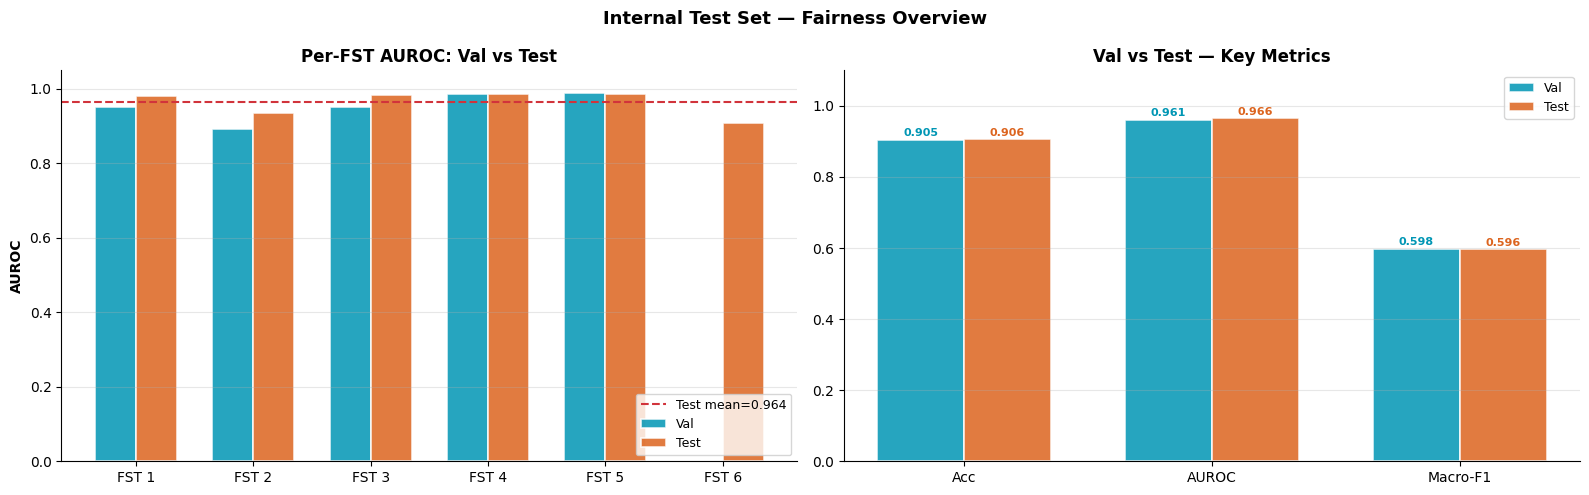

In [19]:
# ════════════════════════════════════════════════════════════════════════════
# INTERNAL TEST SET EVALUATION  (held-out 20 % of training datasets)
# ════════════════════════════════════════════════════════════════════════════
if test_loader is not None:
    print('\n── Internal Test Set Evaluation ─────────────────────────────')
    test_res  = validate(model, test_loader)
    test_fair = fairness(test_res)

    print(f'  Acc={test_res["acc"]:.4f}  AUROC={test_res["auroc"]:.4f}  '
          f'F1={test_res["macro_f1"]:.4f}')
    print('\n── Fairness Metrics (test) ───────────────────────────────────')
    for m, arrow in [('EOM','↑'),('PQD','↓'),('DPM','↓'),('FATE','↑')]:
        print(f'  {m} ({arrow}): {_fmt(test_fair[m])}')
    print('\n── Per-FST AUROC (test) ──────────────────────────────────────')
    for g, v in test_fair['pg'].items():
        bar = '#'*int(v*20) if not np.isnan(v) else 'n/a'
        print(f'  FST {g+1}: {_fmt(v)}  {bar}')

    # Quick comparison table: val vs test
    print('\n── Val vs Test Summary ───────────────────────────────────────')
    compare_df = pd.DataFrame({
        'Val' : {'Acc': vr['acc'], 'AUROC': vr['auroc'], 'Macro-F1': vr['macro_f1'],
                  'EOM': fr['EOM'], 'FATE': fr['FATE']},
        'Test': {'Acc': test_res['acc'], 'AUROC': test_res['auroc'],
                  'Macro-F1': test_res['macro_f1'],
                  'EOM': test_fair['EOM'], 'FATE': test_fair['FATE']},
    }).round(4)
    print(compare_df.to_string())
    compare_df.to_csv(CFG['results_dir']/'val_vs_test_eval.csv')

    # ── Visual: Test set per-FST AUROC bar chart ──────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Internal Test Set — Fairness Overview', fontsize=13, fontweight='bold')

    # Per-FST AUROC
    t_vals   = [test_fair['pg'].get(i, float('nan')) for i in range(6)]
    v_vals   = [fr['pg'].get(i, float('nan')) for i in range(6)]
    grp_lbls = [f'FST {i+1}' for i in range(6)]
    x        = np.arange(6); w = 0.35
    bars_v   = axes[0].bar(x - w/2, [0 if np.isnan(v) else v for v in v_vals],
                            w, label='Val',  color='#0096B4', edgecolor='white', lw=1.2, alpha=0.85)
    bars_t   = axes[0].bar(x + w/2, [0 if np.isnan(v) else v for v in t_vals],
                            w, label='Test', color='#DC641E', edgecolor='white', lw=1.2, alpha=0.85)
    axes[0].axhline(np.nanmean(t_vals), ls='--', color='#D1333B', lw=1.5,
                    label=f'Test mean={np.nanmean(t_vals):.3f}')
    axes[0].set_xticks(x); axes[0].set_xticklabels(grp_lbls)
    axes[0].set_ylim(0, 1.05); axes[0].set_ylabel('AUROC', fontweight='bold')
    axes[0].set_title('Per-FST AUROC: Val vs Test', fontweight='bold')
    axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)
    axes[0].spines[['top','right']].set_visible(False)

    # Summary metric comparison bar chart
    metrics = ['Acc', 'AUROC', 'Macro-F1']
    vals_v = [vr['acc'], vr['auroc'], vr['macro_f1']]
    vals_t = [test_res['acc'], test_res['auroc'], test_res['macro_f1']]
    x2 = np.arange(len(metrics)); w2 = 0.35
    axes[1].bar(x2 - w2/2, vals_v, w2, label='Val',  color='#0096B4', edgecolor='white', lw=1.2, alpha=0.85)
    axes[1].bar(x2 + w2/2, vals_t, w2, label='Test', color='#DC641E', edgecolor='white', lw=1.2, alpha=0.85)
    for i, (vv, vt) in enumerate(zip(vals_v, vals_t)):
        axes[1].text(i - w2/2, vv + 0.01, f'{vv:.3f}', ha='center', fontsize=8, fontweight='bold', color='#0096B4')
        axes[1].text(i + w2/2, vt + 0.01, f'{vt:.3f}', ha='center', fontsize=8, fontweight='bold', color='#DC641E')
    axes[1].set_xticks(x2); axes[1].set_xticklabels(metrics)
    axes[1].set_ylim(0, 1.1); axes[1].set_title('Val vs Test — Key Metrics', fontweight='bold')
    axes[1].legend(fontsize=9); axes[1].grid(axis='y', alpha=0.3)
    axes[1].spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(CFG['results_dir']/'test_eval_overview.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('[SKIP] test_loader is None — skipping internal test evaluation')
    test_res = test_fair = None


In [20]:
# ── Cross-dataset evaluation ──────────────────────────────────────────────
cross_results = {}
for ds_name, loader in eval_loaders.items():
    res  = validate(model, loader)
    fair = fairness(res)
    cross_results[ds_name] = {
        'AUROC'   : res['auroc'],
        'Macro-F1': res['macro_f1'],
        'EOM'     : fair['EOM'],
        'PQD'     : fair['PQD'],
        'FATE'    : fair['FATE'],
    }
    # _fmt() handles nan gracefully — avoids crash when EOM/FATE are nan
    print(f'{ds_name:<12}  AUROC={_fmt(res["auroc"])}  '
          f'EOM={_fmt(fair["EOM"])}  FATE={_fmt(fair["FATE"])}')

cross_df = pd.DataFrame(cross_results).T.round(4)
cross_df.to_csv(CFG['results_dir']/'cross_dataset_eval.csv')

# EOM/PQD/DPM/FATE are nan for datasets without FST annotations (e.g. Dermnet).
# Only AUROC and Macro-F1 are meaningful for such datasets.
has_fst = cross_df['EOM'].notna().any()
if not has_fst:
    print('\n[INFO] EOM/FATE=nan: no eval dataset has FST annotations.')
    print('       AUROC and Macro-F1 are the only valid metrics here.')
print('\n', cross_df[['AUROC','Macro-F1']].to_string())
if has_fst:
    print('\n', cross_df.to_string())

Val:   0%|          | 0/306 [00:00<?, ?it/s]

dermnet       AUROC=0.6925  EOM=0.9776  FATE=0.8350

           AUROC  Macro-F1
dermnet  0.6925     0.205

           AUROC  Macro-F1     EOM    PQD   FATE
dermnet  0.6925     0.205  0.9776  0.067  0.835


## Phase 6 — Ablation Studies

In [21]:
QUICK = True; ABL_EP = 1 if QUICK else CFG['num_epochs']
configs = {
    'Full Model'           :dict(use_conf=True, use_con=True, use_mi=True),
    'w/o L_MI'             :dict(use_conf=True, use_con=True, use_mi=False),
    'w/o L_conf'           :dict(use_conf=False,use_con=True, use_mi=True),
    'w/o L_con'            :dict(use_conf=True, use_con=False,use_mi=True),
    'L_cls only (baseline)':dict(use_conf=False,use_con=False,use_mi=False),
}
abl_res = {}
for name, flags in configs.items():
    print(f'\n{"="*55}  {name}')
    m = DualEncoderModel(CFG['backbone'],CFG['embed_dim'],
                         CFG['num_classes'],CFG['num_skin_types'],True).to(DEVICE)
    o = torch.optim.AdamW(m.parameters(), lr=CFG['lr'])
    c = {**CFG, **flags}
    for ep in range(ABL_EP): train_epoch(m, train_loader, o, c, ep)
    res=validate(m,val_loader); fair=fairness(res)
    abl_res[name]={'AUROC':res['auroc'],'Macro-F1':res['macro_f1'],
                   'EOM':fair['EOM'],'PQD':fair['PQD'],'FATE':fair['FATE']}
    print(f'  AUROC={res["auroc"]:.4f}  EOM={fair["EOM"]:.4f}  FATE={fair["FATE"]:.4f}')
    del m; torch.cuda.empty_cache()

abl_df = pd.DataFrame(abl_res).T.round(4)
abl_df.to_csv(CFG['results_dir']/'ablation_results.csv')
print('\n', abl_df.to_string())


=======================================================  Full Model
DualEncoderModel  backbone=vit_small_patch16_224  feat=384  embed=512  params=44.4M


Train E1:   0%|          | 0/1340 [00:00<?, ?it/s]

Val:   0%|          | 0/63 [00:00<?, ?it/s]

    [pg_auroc] FST 6: only class [6] present (83 samples) — AUROC=nan
  AUROC=0.9349  EOM=0.9450  FATE=0.9399

=======================================================  w/o L_MI
DualEncoderModel  backbone=vit_small_patch16_224  feat=384  embed=512  params=44.4M


Train E1:   0%|          | 0/1340 [00:00<?, ?it/s]

...

Val:   0%|          | 0/63 [00:00<?, ?it/s]

    [pg_auroc] FST 6: only class [6] present (83 samples) — AUROC=nan
  AUROC=0.9531  EOM=0.9685  FATE=0.9608

=======================================================  L_cls only (baseline)
DualEncoderModel  backbone=vit_small_patch16_224  feat=384  embed=512  params=44.4M


Train E1:   0%|          | 0/1340 [00:00<?, ?it/s]

Val:   0%|          | 0/63 [00:00<?, ?it/s]

    [pg_auroc] FST 6: only class [6] present (83 samples) — AUROC=nan
  AUROC=0.9521  EOM=0.9648  FATE=0.9585

                         AUROC  Macro-F1     EOM     PQD    FATE
Full Model             0.9349    0.6864  0.9450  0.1548  0.9399
w/o L_MI               0.9473    0.7119  0.9608  0.1158  0.9540
w/o L_conf             0.9361    0.7023  0.9762  0.0726  0.9561
w/o L_con              0.9531    0.6722  0.9685  0.0865  0.9608
L_cls only (baseline)  0.9521    0.6356  0.9648  0.1078  0.9585


## Phase 7 — Visualization

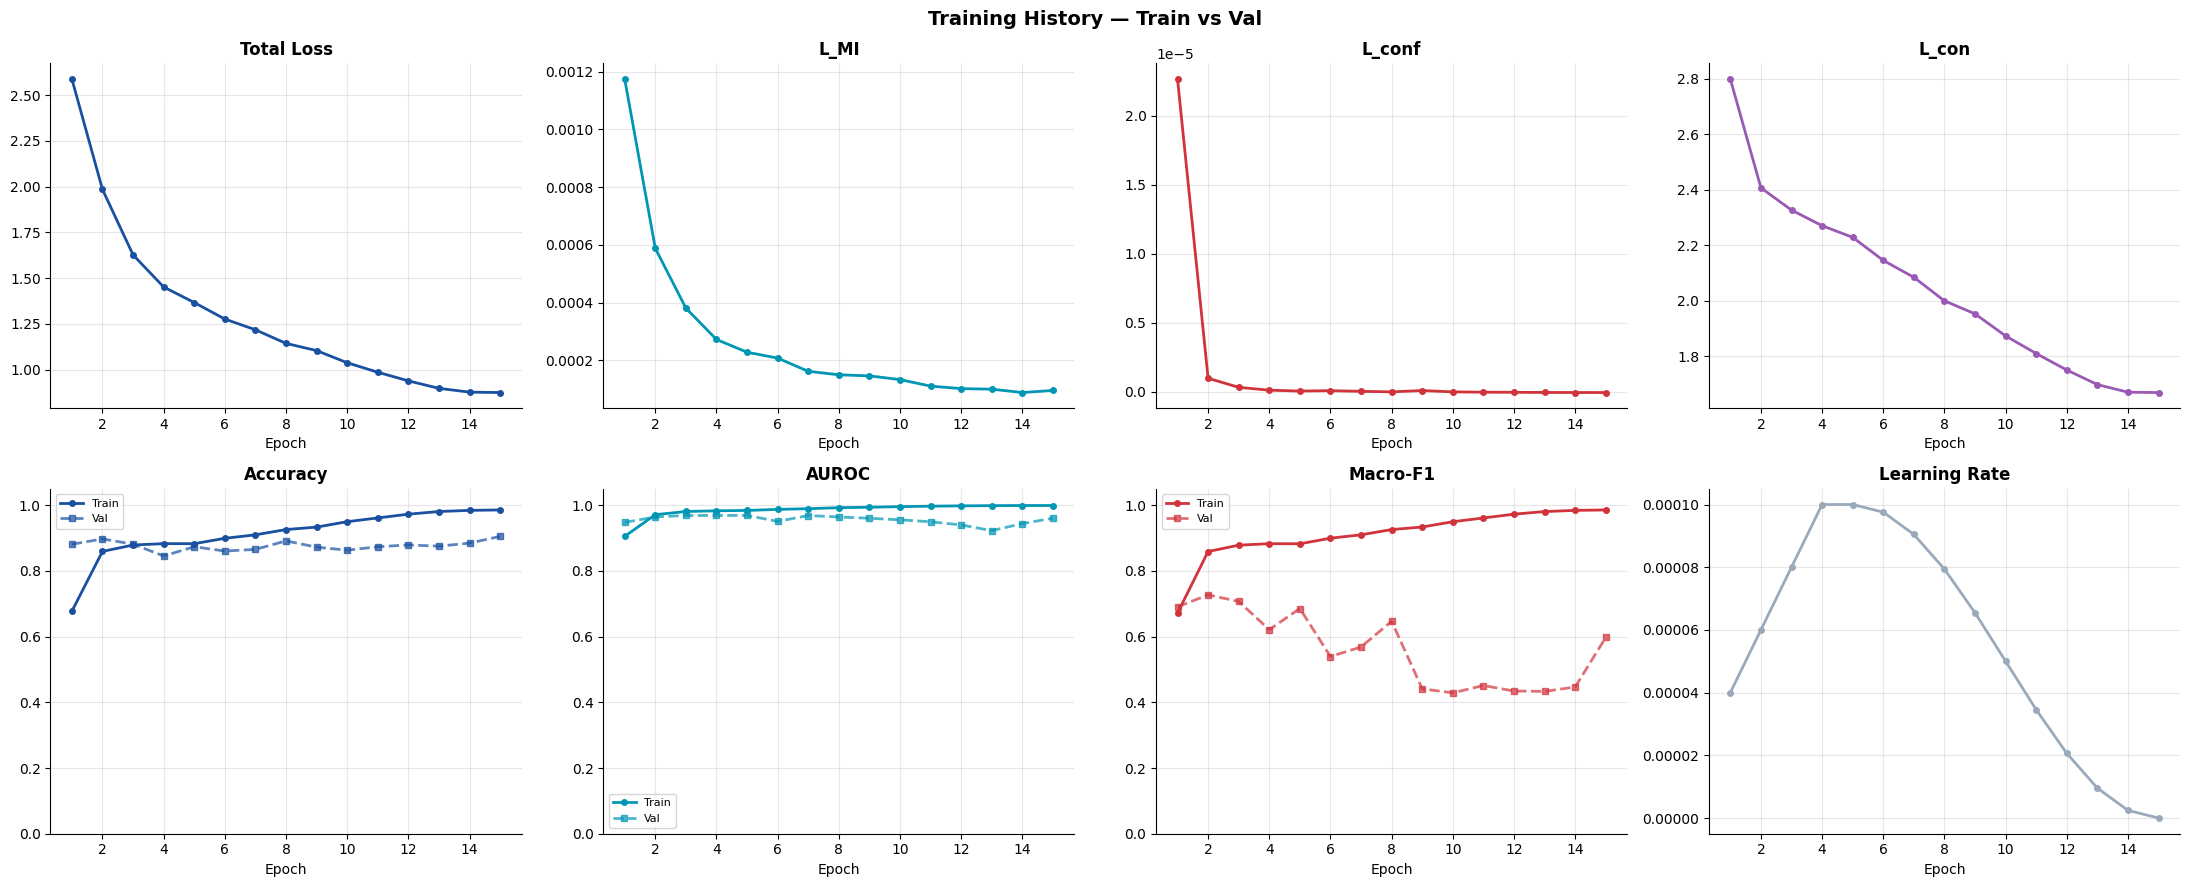

In [22]:
# ── Training curves (train + val side-by-side) ──────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.suptitle('Training History — Train vs Val', fontsize=14, fontweight='bold')

epochs_x = list(range(1, len(history.get('train_total', [])) + 1))

# Row 0 — Loss curves
for ax, key, title, color in [
    (axes[0,0], 'train_total', 'Total Loss',  '#1950A0'),
    (axes[0,1], 'train_mi',    'L_MI',         '#0096B4'),
    (axes[0,2], 'train_conf',  'L_conf',       '#D1333B'),
    (axes[0,3], 'train_con',   'L_con',        '#9B59B6'),
]:
    if history.get(key):
        ax.plot(epochs_x, history[key], color=color, lw=2, marker='o', ms=4)
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3); ax.spines[['top','right']].set_visible(False)

# Row 1 — Classification metrics: train (solid) vs val (dashed)
for ax, t_key, v_key, title, color in [
    (axes[1,0], 'train_acc',      'val_acc',      'Accuracy',  '#1950A0'),
    (axes[1,1], 'train_auroc',    'val_auroc',    'AUROC',     '#0096B4'),
    (axes[1,2], 'train_macro_f1', 'val_macro_f1', 'Macro-F1',  '#D1333B'),
    (axes[1,3], 'lr',             None,           'Learning Rate', '#9AAABB'),
]:
    if history.get(t_key):
        ax.plot(epochs_x, history[t_key], color=color, lw=2, marker='o', ms=4,
                label='Train', linestyle='-')
    if v_key and history.get(v_key):
        ax.plot(epochs_x, history[v_key], color=color, lw=2, marker='s', ms=4,
                label='Val', linestyle='--', alpha=0.7)
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Epoch')
    if t_key != 'lr': ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3); ax.spines[['top','right']].set_visible(False)
    if v_key: ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(CFG['results_dir']/'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

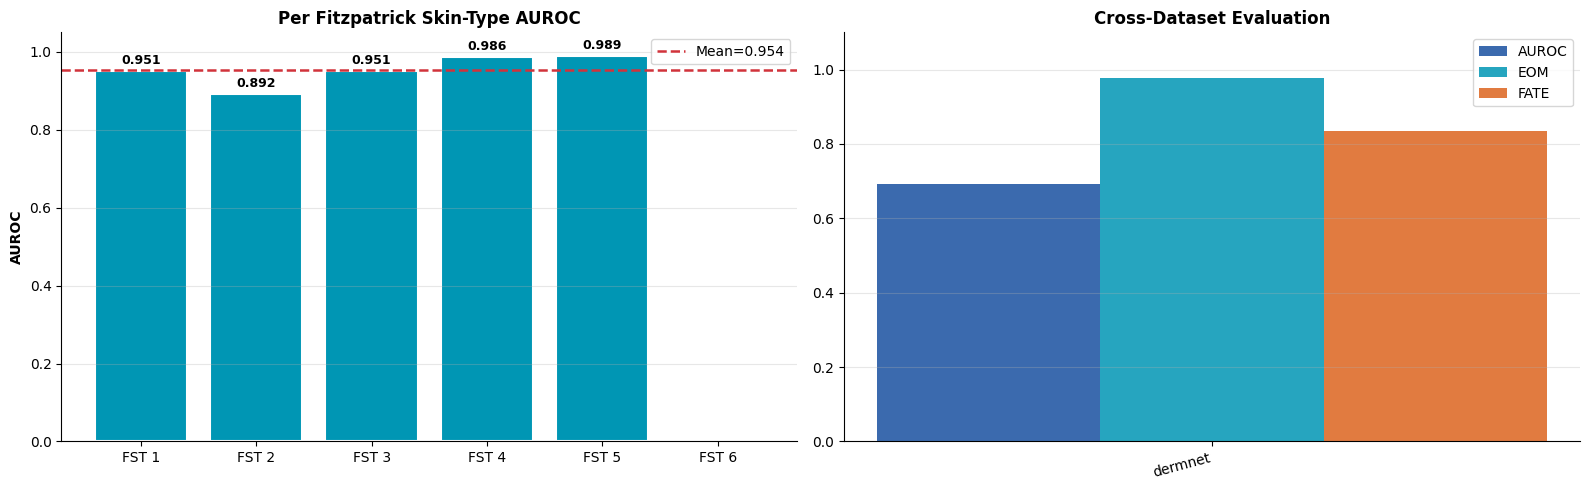

In [23]:
# ── Per-FST AUROC + cross-dataset comparison ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# FST bars
vals   = [fr['pg'].get(i, float('nan')) for i in range(6)]
groups = [f'FST {i+1}' for i in range(6)]
colors = ['#0096B4' if not np.isnan(v) else '#CCCCCC' for v in vals]
bars   = axes[0].bar(groups, [0 if np.isnan(v) else v for v in vals],
                     color=colors, edgecolor='white', lw=1.5)
axes[0].axhline(np.nanmean(vals), ls='--', color='#D1333B', lw=1.8,
                label=f'Mean={np.nanmean(vals):.3f}')
for b,v in zip(bars,vals):
    if not np.isnan(v):
        axes[0].text(b.get_x()+b.get_width()/2, v+0.01,
                     f'{v:.3f}',ha='center',va='bottom',fontsize=9,fontweight='bold')
axes[0].set_ylim(0,1.05); axes[0].set_ylabel('AUROC',fontweight='bold')
axes[0].set_title('Per Fitzpatrick Skin-Type AUROC',fontweight='bold',fontsize=12)
axes[0].legend(); axes[0].grid(axis='y',alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# Cross-dataset
if cross_results:
    df=pd.DataFrame(cross_results).T
    x=np.arange(len(df)); w=0.22
    for i,(m,c) in enumerate(zip(['AUROC','EOM','FATE'],['#1950A0','#0096B4','#DC641E'])):
        axes[1].bar(x+(i-1)*w, df[m].values, w, label=m, color=c, alpha=0.85)
    axes[1].set_xticks(x); axes[1].set_xticklabels(df.index,rotation=15,ha='right')
    axes[1].set_title('Cross-Dataset Evaluation',fontweight='bold',fontsize=12)
    axes[1].legend(); axes[1].set_ylim(0,1.1); axes[1].grid(axis='y',alpha=0.3)
    axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(CFG['results_dir']/'eval_overview.png',dpi=150,bbox_inches='tight')
plt.show()

2026-04-17 08:05:02.346464: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776413102.576141      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776413102.640803      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776413103.189854      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776413103.189895      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776413103.189898      55 computation_placer.cc:177] computation placer alr

Computing UMAP ...
Computing t-SNE (perplexity=40) ...


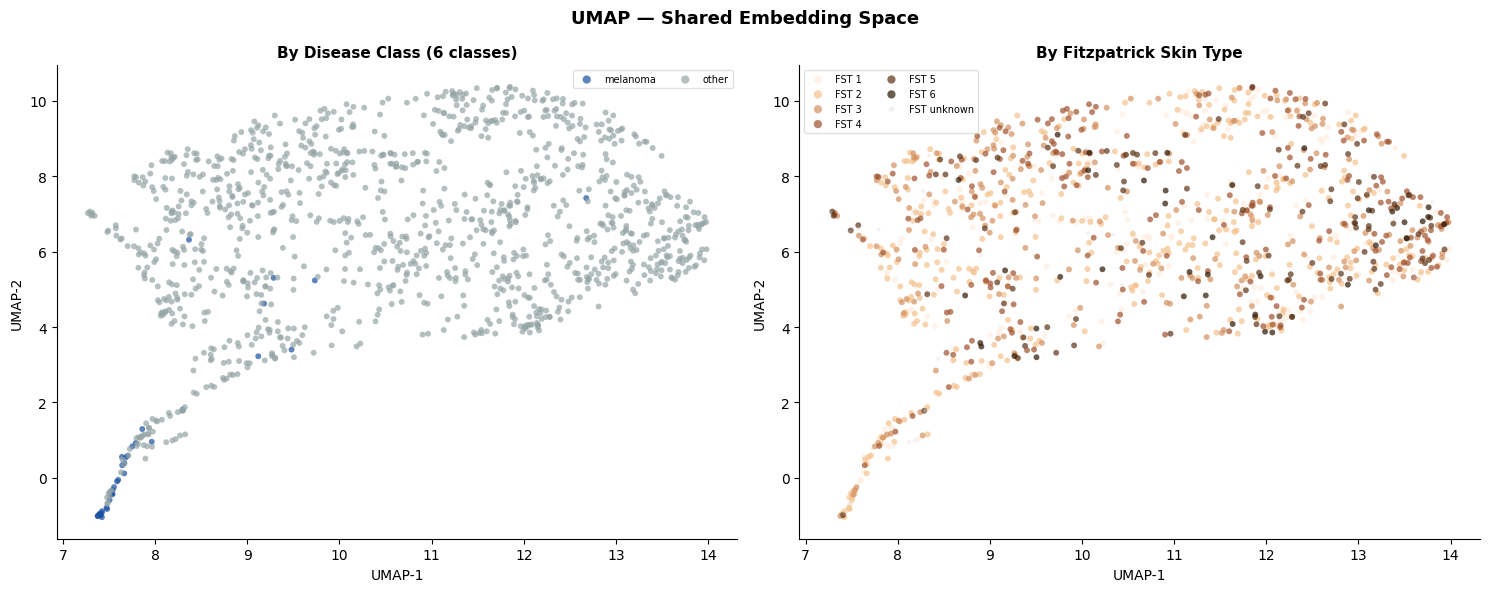

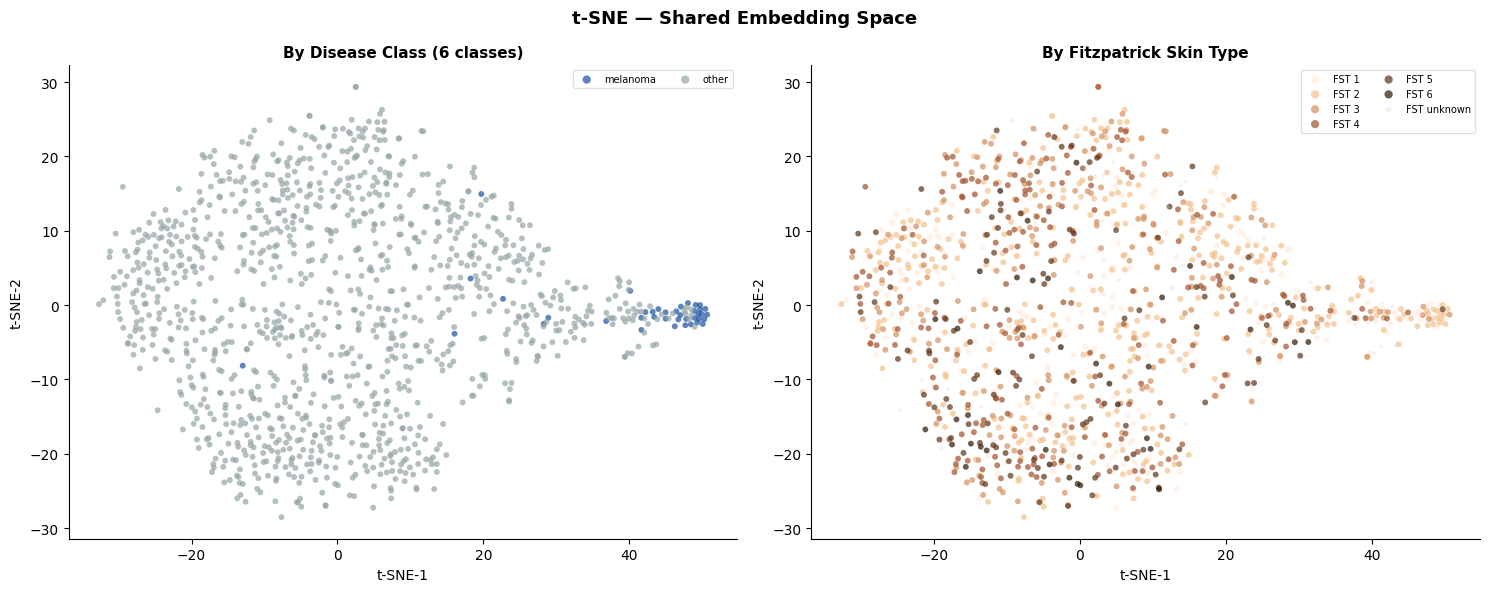

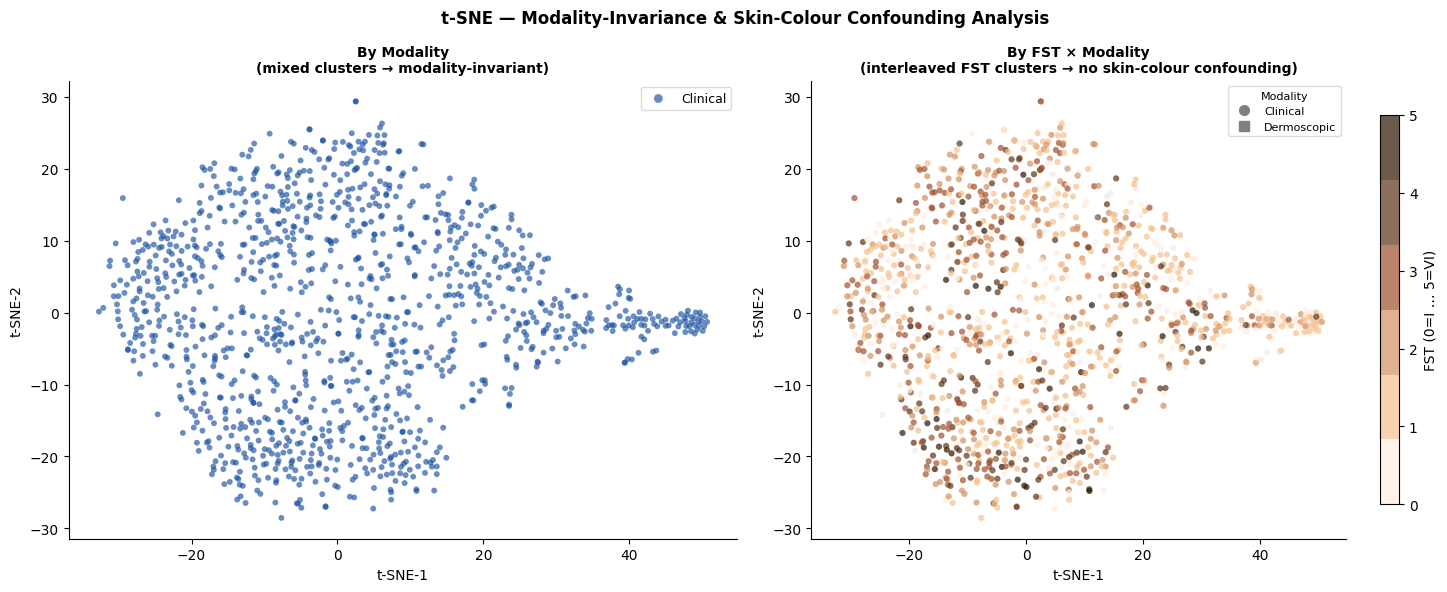

UMAP and t-SNE figures saved.


In [24]:
# ── UMAP + t-SNE of shared embedding space ───────────────────────────────
import os as _os, sys as _sys
from umap import UMAP
from sklearn.manifold import TSNE
from matplotlib.colors import ListedColormap as _LC
from matplotlib.lines import Line2D

# ── Extended extractor: also capture modality ─────────────────────────────
@torch.no_grad()
def extract_embeddings(loader, max_n=1200):
    """Extract (embedding, label, skin_type, modality) from a loader."""
    model.eval()
    Zs, Ls, Ss, Ms = [], [], [], []
    for batch in loader:
        for k, v in batch.items():
            if isinstance(v, torch.Tensor): batch[k] = v.to(DEVICE)
        out = model(batch)
        Zs.append(out['z'].cpu())
        Ls.append(batch['label'].cpu())
        Ss.append(batch['skin_type'].cpu())
        # modality: 0=clinical, 1=derm
        mod_int = torch.tensor(
            [1 if m == 'derm' else 0 for m in batch.get('modality', ['clinical']*len(batch['label']))],
            dtype=torch.long)
        Ms.append(mod_int)
        if sum(len(z) for z in Zs) >= max_n:
            break
    return (torch.cat(Zs)[:max_n].numpy(),
            torch.cat(Ls)[:max_n].numpy(),
            torch.cat(Ss)[:max_n].numpy(),
            torch.cat(Ms)[:max_n].numpy())

embs, labs, skins, mods = extract_embeddings(val_loader)

# Suppress harmless stderr warnings (TF vs PyTorch CUDA registration)
class _SuppressStderr:
    def __enter__(self):
        self._real_fd  = _sys.stderr.fileno()
        self._saved_fd = _os.dup(self._real_fd)
        self._devnull  = _os.open(_os.devnull, _os.O_WRONLY)
        _os.dup2(self._devnull, self._real_fd)
        return self
    def __exit__(self, *_):
        _os.dup2(self._saved_fd, self._real_fd)
        _os.close(self._saved_fd)
        _os.close(self._devnull)

# ── Compute UMAP ─────────────────────────────────────────────────────────
print('Computing UMAP ...')
with _SuppressStderr():
    e2d_umap = UMAP(n_components=2, random_state=SEED, n_neighbors=15,
                    min_dist=0.1).fit_transform(embs)

# ── Compute t-SNE ────────────────────────────────────────────────────────
print('Computing t-SNE (perplexity=40) ...')
e2d_tsne = TSNE(n_components=2, random_state=SEED, perplexity=40,
                n_iter=1000, learning_rate='auto', init='pca').fit_transform(embs)

# ── Colour maps ──────────────────────────────────────────────────────────
_N_CLS  = CFG['num_classes']   # 7
_CLS_COLORS = ['#1950A0','#0096B4','#DC641E','#2ECC71','#9B59B6','#E74C3C','#95A5A6']
_CLS_NAMES  = {0:'melanoma',1:'nevus',2:'basal cell ca.',3:'actinic ker.',4:'seborrh. ker.',5:'squamous cc.',6:'other'}
_FST_COLORS = ['#FFEDE0','#F4C18C','#D49060','#A0522D','#5C3317','#2B1500']
_FST_EDGEC  = ['#999999','#888888','#777777','#555555','#333333','#000000']
fst_cmap    = _LC(_FST_COLORS)

def _scatter_labeled(ax, xy, color_ids, palette, labels_map, title,
                     xlabel='Dim-1', ylabel='Dim-2', s=18, alpha=0.7):
    """Scatter with a manual legend entry per unique id."""
    for cid in sorted(set(color_ids)):
        mask = color_ids == cid
        ax.scatter(xy[mask, 0], xy[mask, 1],
                   c=palette[cid % len(palette)], s=s, alpha=alpha,
                   label=labels_map.get(cid, str(cid)), edgecolors='none')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.legend(fontsize=7, markerscale=1.4, framealpha=0.6,
              loc='best', ncol=2)
    ax.spines[['top','right']].set_visible(False)

# ═══════════════════════════════════════════════════════════════════
# FIGURE A — UMAP (2 panels: disease class | FST)
# ═══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('UMAP — Shared Embedding Space', fontsize=13, fontweight='bold')

_scatter_labeled(axes[0], e2d_umap, labs, _CLS_COLORS, _CLS_NAMES,
                 'By Disease Class (6 classes)', 'UMAP-1', 'UMAP-2')

mk = skins >= 0
_fst_map = {i: f'FST {i+1}' for i in range(6)}
_scatter_labeled(axes[1], e2d_umap[mk], skins[mk], _FST_COLORS, _fst_map,
                 'By Fitzpatrick Skin Type', 'UMAP-1', 'UMAP-2')
if (~mk).any():
    axes[1].scatter(e2d_umap[~mk, 0], e2d_umap[~mk, 1],
                    c='#CCCCCC', s=8, alpha=0.25, label='FST unknown', edgecolors='none')
    axes[1].legend(fontsize=7, markerscale=1.4, framealpha=0.6, ncol=2)

plt.tight_layout()
plt.savefig(CFG['results_dir']/'umap_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════
# FIGURE B — t-SNE (2 panels: disease class | FST)
# ═══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('t-SNE — Shared Embedding Space', fontsize=13, fontweight='bold')

_scatter_labeled(axes[0], e2d_tsne, labs, _CLS_COLORS, _CLS_NAMES,
                 'By Disease Class (6 classes)', 't-SNE-1', 't-SNE-2')
_scatter_labeled(axes[1], e2d_tsne[mk], skins[mk], _FST_COLORS, _fst_map,
                 'By Fitzpatrick Skin Type', 't-SNE-1', 't-SNE-2')
if (~mk).any():
    axes[1].scatter(e2d_tsne[~mk, 0], e2d_tsne[~mk, 1],
                    c='#CCCCCC', s=8, alpha=0.25, label='FST unknown', edgecolors='none')
    axes[1].legend(fontsize=7, markerscale=1.4, framealpha=0.6, ncol=2)

plt.tight_layout()
plt.savefig(CFG['results_dir']/'tsne_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════
# FIGURE C — t-SNE: Modality-Invariance Verification
#
# Supervisor's request: show that modality-invariant representations
# are NOT confounded by skin colour.
#
# Panel 1 — colour = modality (clinical vs dermoscopic)
#            → clusters should mix modalities, NOT separate them
# Panel 2 — colour = FST, marker shape = modality
#            → if the model is modality-invariant, same-FST points
#              from both modalities should overlap, and FST clusters
#              should be diffuse / interleaved (not separating by skin tone)
# ═══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('t-SNE — Modality-Invariance & Skin-Colour Confounding Analysis',
             fontsize=12, fontweight='bold')

# Panel 1: colour by modality
_MOD_COLORS = {0: '#1950A0', 1: '#DC641E'}
_MOD_NAMES  = {0: 'Clinical', 1: 'Dermoscopic'}
for mid in [0, 1]:
    mask = mods == mid
    if mask.any():
        axes[0].scatter(e2d_tsne[mask, 0], e2d_tsne[mask, 1],
                        c=_MOD_COLORS[mid], s=18, alpha=0.65,
                        label=_MOD_NAMES[mid], edgecolors='none')
axes[0].set_title('By Modality\n(mixed clusters → modality-invariant)',
                  fontweight='bold', fontsize=10)
axes[0].set_xlabel('t-SNE-1'); axes[0].set_ylabel('t-SNE-2')
axes[0].legend(fontsize=9, markerscale=1.5, framealpha=0.7)
axes[0].spines[['top','right']].set_visible(False)

# Panel 2: marker shape = modality, colour = FST
_MARKERS = {0: 'o', 1: 's'}    # circle = clinical, square = derm
_MK_SIZE  = {0: 20,  1: 16}
for mid in [0, 1]:
    m_mask = mods == mid
    fst_sub = skins[m_mask]
    xy_sub  = e2d_tsne[m_mask]
    known   = fst_sub >= 0
    if known.any():
        sc = axes[1].scatter(xy_sub[known, 0], xy_sub[known, 1],
                             c=fst_sub[known], cmap=fst_cmap,
                             vmin=0, vmax=5,
                             marker=_MARKERS[mid],
                             s=_MK_SIZE[mid], alpha=0.7,
                             edgecolors='none',
                             label=_MOD_NAMES[mid])
    if (~known).any():
        axes[1].scatter(xy_sub[~known, 0], xy_sub[~known, 1],
                        c='#CCCCCC', marker=_MARKERS[mid],
                        s=_MK_SIZE[mid], alpha=0.25, edgecolors='none')

plt.colorbar(sc, ax=axes[1], label='FST (0=I … 5=VI)', shrink=0.85)

# Custom legend: modality shapes
_legend_handles = [
    Line2D([0],[0], marker='o', color='grey', ms=7, ls='none', label='Clinical'),
    Line2D([0],[0], marker='s', color='grey', ms=7, ls='none', label='Dermoscopic'),
]
axes[1].legend(handles=_legend_handles, fontsize=8, title='Modality',
               title_fontsize=8, framealpha=0.7)
axes[1].set_title('By FST × Modality\n(interleaved FST clusters → no skin-colour confounding)',
                  fontweight='bold', fontsize=10)
axes[1].set_xlabel('t-SNE-1'); axes[1].set_ylabel('t-SNE-2')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(CFG['results_dir']/'tsne_modality_invariance.png', dpi=150, bbox_inches='tight')
plt.show()

print('UMAP and t-SNE figures saved.')

## Summary

| Phase | Content |
|-------|---------|
| 0 | GPU + Drive setup |
| 1 | **7-class** taxonomy (melanoma, nevus, BCC, AK, SebKer, SCC, other); consistent lowercase labels; per-image DermNet parsing; train-only augmentation with justification; full EDA |
| 2 | Dual-encoder ViT + shared projection head |
| 3 | $\mathcal{L}_{cls}$ + $\mathcal{L}_{conf}$ + $\mathcal{L}_{con}$ + $\mathcal{L}_{MI}$ |
| 4 | Mixed paired/unpaired training, checkpoints saved every epoch |
| 5 | Accuracy + EOM, PQD, DPM, FATE across FST groups + cross-dataset |
| 6 | 5-variant ablation study |
| 7 | Training curves, FST bars, cross-dataset comparison, UMAP |

### Next steps
1. Upgrade to `vit_base_patch16_224` for final paper runs
2. Sweep $\lambda_1…\lambda_4$ with `wandb`
3. Compare FairDisCo, PatchAlign, FairAdaBN on identical splits — include their SHAP divergence scores for a fair comparison